<font size="6">PROJET 4 : Segmentez des clients d un site e-commerce </font>

**Librairies**

In [ ]:
# Data analyse
import pandas as pd
import numpy as np

In [ ]:
# Visualisation
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import plotly.express as px
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D

In [154]:
pip install -U scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 51.1 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.3/30.3 MB 73.7 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [155]:
# Preprocess
from sklearn.metrics import silhouette_score
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn import (manifold, datasets, decomposition, ensemble,discriminant_analysis, random_projection)

In [156]:
# Modèles
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE

# Chargement des données

In [ ]:
cd /Users/garbamoussa/Downloads/TP-1-Customer-Intelligence-de-la-Data-au-Machine-Learning-main/data

In [ ]:
# Chargement des csv depuis les fichiers téléchargés sur le site kaggle
customers = pd.read_csv("olist_customers_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
orderitem = pd.read_csv("olist_order_items_dataset.csv")
orderpayment = pd.read_csv("olist_order_payments_dataset.csv")
orderreview = pd.read_csv("olist_order_reviews_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
productcategory = pd.read_csv("product_category_name_translation.csv")

Etude des shapes et colonnes de chaque dataset pour identifier les clés principales/étrangères pour fusionner par la suite les dataset en un seul.

In [8]:
print(customers.shape)
customers.columns

(99441, 5)


Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

In [9]:
print(orders.shape)
orders.columns

(99441, 8)


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [10]:
print(geolocation.shape)
geolocation.columns

(1000163, 5)


Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='object')

In [11]:
print(orderitem.shape)
orderitem.columns

(112650, 7)


Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

In [12]:
print(orderpayment.shape)
orderpayment.columns

(103886, 5)


Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

In [13]:
print(orderreview.shape)
orderreview.columns

(99224, 7)


Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')

In [14]:
print(products.shape)
products.columns

(32951, 9)


Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [15]:
print(sellers.shape)
sellers.columns

(3095, 4)


Index(['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state'], dtype='object')

In [16]:
print(productcategory.shape)
productcategory.columns

(71, 2)


Index(['product_category_name', 'product_category_name_english'], dtype='object')

# Merge des datasets

**Merge des datasets geolocation avec customers et geolocation avec sellers, pour ajouter les coordonnées lat/long aux villes**

In [17]:
# Un même zip_code correspond à plusieurs location lat/long
geolocation.sort_values(by='geolocation_zip_code_prefix').head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
1246,1001,-23.549292,-46.633559,sao paulo,SP
429,1001,-23.550498,-46.634338,sao paulo,SP
1182,1001,-23.549779,-46.633957,sao paulo,SP
1435,1001,-23.549292,-46.633559,sao paulo,SP
326,1001,-23.551427,-46.634074,sao paulo,SP


In [18]:
# On groupe les zip_code en moyennant les coordonnées lat et long
geolocation_gb = geolocation[['geolocation_zip_code_prefix',
                              'geolocation_lat',
                              'geolocation_lng']].groupby(by='geolocation_zip_code_prefix').mean().reset_index()

In [19]:
geolocation_gb.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,1001,-23.550190,-46.634024
1,1002,-23.548146,-46.634979
2,1003,-23.548994,-46.635731
3,1004,-23.549799,-46.634757
4,1005,-23.549456,-46.636733


In [20]:
customersgeo = customers.merge(geolocation_gb, left_on='customer_zip_code_prefix',
                               right_on='geolocation_zip_code_prefix', how ='left')

In [21]:
customersgeo.drop(['geolocation_zip_code_prefix'], axis=1, inplace=True)

In [22]:
customersgeo.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_lat,geolocation_lng
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.498489,-47.396929
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,-23.727992,-46.542848
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,-23.531642,-46.656289
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,-23.499702,-46.185233
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,-22.975100,-47.142925


In [23]:
customersgeo.shape

(99441, 7)

In [24]:
sellersgeo = sellers.merge(geolocation_gb, left_on='seller_zip_code_prefix',
                               right_on='geolocation_zip_code_prefix', how ='left')

In [25]:
sellersgeo.drop(['geolocation_zip_code_prefix'], axis=1, inplace=True)

In [26]:
sellersgeo.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state,geolocation_lat,geolocation_lng
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,-22.893848,-47.061337
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,-22.383437,-46.947927
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ,-22.909572,-43.177703
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP,-23.657242,-46.612831
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP,-22.964803,-46.534419


In [27]:
sellersgeo.shape

(3095, 6)

**On commence par fusionner les datasets orders et customersgeo, qui ont le même nombre de lignes**

In [28]:
orders_customers = orders.merge(customersgeo, how = 'outer', on = 'customer_id')

In [29]:
orders_customers.shape

(99441, 14)

In [30]:
orders_customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_lat,geolocation_lng
0,5f79b5b0931d63f1a42989eb65b9da6e,00012a2ce6f8dcda20d059ce98491703,delivered,2017-11-14 16:08:26,2017-11-14 16:35:32,2017-11-17 15:32:08,2017-11-28 15:41:30,2017-12-04 00:00:00,248ffe10d632bebe4f7267f1f44844c9,6273,osasco,SP,-23.499063,-46.767939
1,a44895d095d7e0702b6a162fa2dbeced,000161a058600d5901f007fab4c27140,delivered,2017-07-16 09:40:32,2017-07-16 09:55:12,2017-07-19 19:09:37,2017-07-25 18:57:33,2017-08-04 00:00:00,b0015e09bb4b6e47c52844fab5fb6638,35550,itapecerica,MG,-20.469754,-45.123242
2,316a104623542e4d75189bb372bc5f8d,0001fd6190edaaf884bcaf3d49edf079,delivered,2017-02-28 11:06:43,2017-02-28 11:15:20,2017-03-01 15:24:20,2017-03-06 08:57:49,2017-03-22 00:00:00,94b11d37cd61cb2994a194d11f89682b,29830,nova venecia,ES,-18.706581,-40.406384
3,5825ce2e88d5346438686b0bba99e5ee,0002414f95344307404f0ace7a26f1d5,delivered,2017-08-16 13:09:20,2017-08-17 03:10:27,2017-08-19 11:34:29,2017-09-13 20:06:02,2017-09-14 00:00:00,4893ad4ea28b2c5b3ddf4e82e79db9e6,39664,mendonca,MG,-21.770599,-43.355230
4,0ab7fb08086d4af9141453c91878ed7a,000379cdec625522490c315e70c7a9fb,delivered,2018-04-02 13:42:17,2018-04-04 03:10:19,2018-04-04 18:11:09,2018-04-13 20:21:08,2018-04-18 00:00:00,0b83f73b19c2019e182fd552c048a22c,4841,sao paulo,SP,-23.738709,-46.689333


**On ajoute ensuite le dataset orderreview**

In [31]:
orderreview.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [32]:
len(orderreview['order_id'].unique())

98673

In [33]:
# On conserve uniquement les colonnes order_id (clé) et review_score et on fait la moyenne car plusieurs notes pour même order
orderreview[orderreview.duplicated('order_id', keep=False) == True].sort_values(by='order_id')

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
25612,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,NaN,NaN,2017-08-29 00:00:00,2017-08-30 01:59:12
22423,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,NaN,Estou acostumada a comprar produtos pelo barat...,2017-08-25 00:00:00,2017-08-29 21:45:57
22779,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,NaN,NaN,2018-02-22 00:00:00,2018-02-23 12:12:30
68633,73413b847f63e02bc752b364f6d05ee9,013056cfe49763c6f66bda03396c5ee3,4,NaN,NaN,2018-03-04 00:00:00,2018-03-05 17:02:00
854,830636803620cdf8b6ffaf1b2f6e92b2,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:06
...,...,...,...,...,...,...,...
27465,5e78482ee783451be6026e5cf0c72de1,ff763b73e473d03c321bcd5a053316e8,3,NaN,Não sei que haverá acontecido os demais chegaram,2017-11-18 00:00:00,2017-11-18 09:02:48
41355,39de8ad3a1a494fc68cc2d5382f052f4,ff850ba359507b996e8b2fbb26df8d03,5,NaN,Envio rapido... Produto 100%,2017-08-16 00:00:00,2017-08-17 11:56:55
18783,80f25f32c00540d49d57796fb6658535,ff850ba359507b996e8b2fbb26df8d03,5,NaN,"Envio rapido, produto conforme descrito no anu...",2017-08-22 00:00:00,2017-08-25 11:40:22
92230,870d856a4873d3a67252b0c51d79b950,ffaabba06c9d293a3c614e0515ddbabc,3,NaN,NaN,2017-12-20 00:00:00,2017-12-20 18:50:16


In [34]:
orderreview_gb = orderreview[['order_id', 'review_score']].groupby(by="order_id").mean().reset_index()
orderreview_gb

,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0
...,...,...
98668,fffc94f6ce00a00581880bf54a75a037,5.0
98669,fffcd46ef2263f404302a634eb57f7eb,5.0
98670,fffce4705a9662cd70adb13d4a31832d,5.0
98671,fffe18544ffabc95dfada21779c9644f,5.0


In [35]:
orders_customers_review = orders_customers.merge(orderreview_gb, how ='left', on = 'order_id')

In [36]:
orders_customers_review.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_lat,geolocation_lng,review_score
0,5f79b5b0931d63f1a42989eb65b9da6e,00012a2ce6f8dcda20d059ce98491703,delivered,2017-11-14 16:08:26,2017-11-14 16:35:32,2017-11-17 15:32:08,2017-11-28 15:41:30,2017-12-04 00:00:00,248ffe10d632bebe4f7267f1f44844c9,6273,osasco,SP,-23.499063,-46.767939,1.0
1,a44895d095d7e0702b6a162fa2dbeced,000161a058600d5901f007fab4c27140,delivered,2017-07-16 09:40:32,2017-07-16 09:55:12,2017-07-19 19:09:37,2017-07-25 18:57:33,2017-08-04 00:00:00,b0015e09bb4b6e47c52844fab5fb6638,35550,itapecerica,MG,-20.469754,-45.123242,4.0
2,316a104623542e4d75189bb372bc5f8d,0001fd6190edaaf884bcaf3d49edf079,delivered,2017-02-28 11:06:43,2017-02-28 11:15:20,2017-03-01 15:24:20,2017-03-06 08:57:49,2017-03-22 00:00:00,94b11d37cd61cb2994a194d11f89682b,29830,nova venecia,ES,-18.706581,-40.406384,5.0
3,5825ce2e88d5346438686b0bba99e5ee,0002414f95344307404f0ace7a26f1d5,delivered,2017-08-16 13:09:20,2017-08-17 03:10:27,2017-08-19 11:34:29,2017-09-13 20:06:02,2017-09-14 00:00:00,4893ad4ea28b2c5b3ddf4e82e79db9e6,39664,mendonca,MG,-21.770599,-43.355230,5.0
4,0ab7fb08086d4af9141453c91878ed7a,000379cdec625522490c315e70c7a9fb,delivered,2018-04-02 13:42:17,2018-04-04 03:10:19,2018-04-04 18:11:09,2018-04-13 20:21:08,2018-04-18 00:00:00,0b83f73b19c2019e182fd552c048a22c,4841,sao paulo,SP,-23.738709,-46.689333,4.0


In [37]:
orders_customers_review.shape

(99441, 15)

In [38]:
len(orders_customers_review['order_id'].unique())

99441

**On ajoute le dataset orderitem**

In [39]:
orderitem.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [40]:
orderitem.shape

(112650, 7)

In [41]:
len(orderitem['order_id'].unique())

98666

In [42]:
# on choisit un merge 'right' car dans le dataset orderitem on ne retrouve pas toutes les order_id du dataset orders.
# Comme c'est dans ce dataset que l'on trouve les prix, on choisit de ne pas avoir de NaN sur la variable.
# orderitem donne tous les produits achetés pour chaque commande (parfois plusieurs sur la même commande)
orders_customers_review_item = orders_customers_review.merge(orderitem, how = 'right', on = 'order_id')

In [43]:
# Chaque commande est bien rattachée à un client
len(orders_customers_review_item['customer_id'].dropna())

112650

In [44]:
orders_customers_review_item.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,customer_state,geolocation_lat,geolocation_lng,review_score,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,871766c5855e863f6eccc05f988b23cb,28013,...,RJ,-21.762775,-41.309633,5.0,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,eb28e67c4c0b83846050ddfb8a35d051,15775,...,SP,-20.220527,-50.903424,4.0,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,3818d81c6709e39d06b2738a8d3a2474,35661,...,MG,-19.870305,-44.593326,5.0,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,af861d436cfc08b2c2ddefd0ba074622,12952,...,SP,-23.089925,-46.611654,4.0,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,64b576fb70d441e8f1b2d7d446e483c5,13226,...,SP,-23.243402,-46.827614,5.0,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [45]:
orders_customers_review_item.shape

(112650, 21)

**On ajoute maintenant le dataset products**

In [46]:
products

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [47]:
orders_customers_review_item_products = orders_customers_review_item.merge(products, how = 'left', on = 'product_id')

In [48]:
orders_customers_review_item_products.shape

(112650, 29)

In [49]:
orders_customers_review_item_products.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,871766c5855e863f6eccc05f988b23cb,28013,...,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,eb28e67c4c0b83846050ddfb8a35d051,15775,...,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,3818d81c6709e39d06b2738a8d3a2474,35661,...,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,af861d436cfc08b2c2ddefd0ba074622,12952,...,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,64b576fb70d441e8f1b2d7d446e483c5,13226,...,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


**On ajoute le dataset sellersgeo**

In [50]:
sellersgeo.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state,geolocation_lat,geolocation_lng
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,-22.893848,-47.061337
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,-22.383437,-46.947927
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ,-22.909572,-43.177703
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP,-23.657242,-46.612831
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP,-22.964803,-46.534419


In [51]:
sellersgeo.shape

(3095, 6)

In [52]:
len(orders_customers_review_item_products['seller_id'].unique())

3095

In [53]:
orders_customers_review_item_products_sellers = orders_customers_review_item_products.merge(sellersgeo,
                                                                                           how = 'outer',
                                                                                           on ='seller_id')

In [54]:
orders_customers_review_item_products_sellers.shape

(112650, 34)

In [55]:
orders_customers_review_item_products_sellers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,geolocation_lat_y,geolocation_lng_y
0,7f39ba4c9052be115350065d07583cac,d7fc82cbeafea77bd0a8fbbf6296e387,delivered,2017-10-18 08:16:34,2017-10-18 23:56:20,2017-10-20 14:29:01,2017-10-27 16:46:05,2017-11-09 00:00:00,9de5797cddb92598755a0f76383ddbbb,35490,...,2.0,11800.0,40.0,43.0,36.0,9080,santo andre,SP,-23.640444,-46.541742
1,9dc8d1a6f16f1b89874c29c9d8d30447,d9442164acf4b03109425633efaa0cfc,delivered,2017-10-12 13:33:22,2017-10-12 13:49:22,2017-10-17 15:42:42,2017-10-24 20:17:44,2017-11-06 00:00:00,9915eb9f74b6c11aaf04833f65b00e93,38600,...,2.0,11800.0,40.0,43.0,36.0,9080,santo andre,SP,-23.640444,-46.541742
2,d455a8cb295653b55abda06d434ab492,944b72539d7e1f7f7fc6e46639ef1fe3,delivered,2017-09-26 22:17:05,2017-09-27 22:24:16,2017-09-29 15:53:03,2017-10-07 16:12:47,2017-10-30 00:00:00,3c7e305796add66698959fc7ad176f6b,87502,...,2.0,11800.0,40.0,43.0,36.0,9080,santo andre,SP,-23.640444,-46.541742
3,006e43460a55bc60c0a437521e426529,23bfd4316e261786deed5a08231c75bc,delivered,2017-05-11 00:24:35,2017-05-11 01:30:22,2017-05-12 12:26:32,2017-05-19 09:51:17,2017-06-02 00:00:00,1df0a296f852bdf1a17b085730f4b894,11431,...,1.0,9000.0,42.0,12.0,39.0,29156,cariacica,ES,-20.278513,-40.411675
4,00dfb074b5c910fbd08e04691c4b712f,a5ced4926d7d8fa71e9be2b007720356,delivered,2017-06-08 19:43:35,2017-06-08 19:55:19,2017-06-09 15:12:41,2017-06-15 09:03:59,2017-07-10 00:00:00,94ea9edee3656707894565f35cb8570d,8671,...,2.0,9050.0,39.0,12.0,42.0,29156,cariacica,ES,-20.278513,-40.411675


**Puis le dataset orderpayment**

In [56]:
orderpayment.sort_values(by='order_id')

,order_id,payment_sequential,payment_type,payment_installments,payment_value
85283,00010242fe8c5a6d1ba2dd792cb16214,1,credit_card,2,72.19
2499,00018f77f2f0320c557190d7a144bdd3,1,credit_card,3,259.83
12393,000229ec398224ef6ca0657da4fc703e,1,credit_card,5,216.87
32971,00024acbcdf0a6daa1e931b038114c75,1,credit_card,2,25.78
98711,00042b26cf59d7ce69dfabb4e55b4fd9,1,credit_card,3,218.04
...,...,...,...,...,...
69123,fffc94f6ce00a00581880bf54a75a037,1,boleto,1,343.40
2776,fffcd46ef2263f404302a634eb57f7eb,1,boleto,1,386.53
58888,fffce4705a9662cd70adb13d4a31832d,1,credit_card,3,116.85
37089,fffe18544ffabc95dfada21779c9644f,1,credit_card,3,64.71


In [59]:
orderpayment.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,1,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,0,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,0,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,1,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,1,128.45


In [60]:
orderpayment["payment_installments"].unique()

array([1, 0])

In [61]:
# payment_installments : payé en une fois ou pas
a = np.array(orderpayment['payment_installments'].values.tolist())
orderpayment['payment_installments'] = np.where(a > 1, 1, 0).tolist()

In [58]:
a

array([8, 1, 1, ..., 1, 5, 1])

In [62]:
orderpayment.sort_values(by='order_id')

,order_id,payment_sequential,payment_type,payment_installments,payment_value
85283,00010242fe8c5a6d1ba2dd792cb16214,1,credit_card,0,72.19
2499,00018f77f2f0320c557190d7a144bdd3,1,credit_card,0,259.83
12393,000229ec398224ef6ca0657da4fc703e,1,credit_card,0,216.87
32971,00024acbcdf0a6daa1e931b038114c75,1,credit_card,0,25.78
98711,00042b26cf59d7ce69dfabb4e55b4fd9,1,credit_card,0,218.04
...,...,...,...,...,...
69123,fffc94f6ce00a00581880bf54a75a037,1,boleto,0,343.40
2776,fffcd46ef2263f404302a634eb57f7eb,1,boleto,0,386.53
58888,fffce4705a9662cd70adb13d4a31832d,1,credit_card,0,116.85
37089,fffe18544ffabc95dfada21779c9644f,1,credit_card,0,64.71


In [63]:
len(orderpayment['order_id'].unique())

99440

In [64]:
len(orders_customers_review_item_products_sellers['order_id'].unique())

98666

In [65]:
# La colonne payment_sequential ne va pas nous intéresser
orderpayment.drop(['payment_sequential'], axis=1, inplace=True)

In [66]:
# On transforme la colonne payment_type en ne gardant que les 2 principaux et les autres en 'autres'
len(orderpayment['payment_type'].unique())

5

In [67]:
orderpayment['payment_type'].unique()

array(['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined'],
      dtype=object)

In [68]:
orderpayment['payment_type'] = orderpayment['payment_type'].replace(['debit_card', 'not_defined', 'voucher'],
                                                                    ['other', 'other', 'other'])

In [69]:
orderpayment.groupby(by='payment_type').count()

,order_id,payment_installments,payment_value
payment_type,,,
boleto,19784,19784,19784
credit_card,76795,76795,76795
other,7307,7307,7307


In [70]:
orderpayment_dum = pd.get_dummies(orderpayment, columns=['payment_type'])

In [71]:
orderpayment_dum.head()

,order_id,payment_installments,payment_value,payment_type_boleto,payment_type_credit_card,payment_type_other
0,b81ef226f3fe1789b1e8b2acac839d17,0,99.33,False,True,False
1,a9810da82917af2d9aefd1278f1dcfa0,0,24.39,False,True,False
2,25e8ea4e93396b6fa0d3dd708e76c1bd,0,65.71,False,True,False
3,ba78997921bbcdc1373bb41e913ab953,0,107.78,False,True,False
4,42fdf880ba16b47b59251dd489d4441a,0,128.45,False,True,False


In [ ]:
# somme des payment_value pour obtenir le panier total et ensuite faire le panier moyen

In [72]:
orderpayment_gb = orderpayment_dum.groupby(by='order_id').agg({'payment_installments':'max',
                                                               'payment_value' : 'sum',
                                                               'payment_type_boleto':'sum',
                                                               'payment_type_credit_card':'sum',
                                                               'payment_type_other':'sum'})
orderpayment_gb = orderpayment_gb.reset_index()
orderpayment_gb

,order_id,payment_installments,payment_value,payment_type_boleto,payment_type_credit_card,payment_type_other
0,00010242fe8c5a6d1ba2dd792cb16214,0,72.19,0,1,0
1,00018f77f2f0320c557190d7a144bdd3,0,259.83,0,1,0
2,000229ec398224ef6ca0657da4fc703e,0,216.87,0,1,0
3,00024acbcdf0a6daa1e931b038114c75,0,25.78,0,1,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,0,218.04,0,1,0
...,...,...,...,...,...,...
99435,fffc94f6ce00a00581880bf54a75a037,0,343.40,1,0,0
99436,fffcd46ef2263f404302a634eb57f7eb,0,386.53,1,0,0
99437,fffce4705a9662cd70adb13d4a31832d,0,116.85,0,1,0
99438,fffe18544ffabc95dfada21779c9644f,0,64.71,0,1,0


In [73]:
orderpayment_gb[orderpayment_gb['order_id'] == 'bfbd0f9bdef84302105ad712db648a6c']

,order_id,payment_installments,payment_value,payment_type_boleto,payment_type_credit_card,payment_type_other


In [ ]:
# On merge le dataset au dataset orders_customers_review_item_products_sellers

In [74]:
orders_customers_review_item_products_sellers_payment = orders_customers_review_item_products_sellers.merge(orderpayment_gb,
                                                                                                           how = 'left',
                                                                                                           on = 'order_id')

In [75]:
orders_customers_review_item_products_sellers_payment

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,seller_zip_code_prefix,seller_city,seller_state,geolocation_lat_y,geolocation_lng_y,payment_installments,payment_value,payment_type_boleto,payment_type_credit_card,payment_type_other
0,7f39ba4c9052be115350065d07583cac,d7fc82cbeafea77bd0a8fbbf6296e387,delivered,2017-10-18 08:16:34,2017-10-18 23:56:20,2017-10-20 14:29:01,2017-10-27 16:46:05,2017-11-09 00:00:00,9de5797cddb92598755a0f76383ddbbb,35490,...,9080,santo andre,SP,-23.640444,-46.541742,0.0,916.02,0.0,1.0,0.0
1,9dc8d1a6f16f1b89874c29c9d8d30447,d9442164acf4b03109425633efaa0cfc,delivered,2017-10-12 13:33:22,2017-10-12 13:49:22,2017-10-17 15:42:42,2017-10-24 20:17:44,2017-11-06 00:00:00,9915eb9f74b6c11aaf04833f65b00e93,38600,...,9080,santo andre,SP,-23.640444,-46.541742,0.0,916.02,0.0,1.0,0.0
2,d455a8cb295653b55abda06d434ab492,944b72539d7e1f7f7fc6e46639ef1fe3,delivered,2017-09-26 22:17:05,2017-09-27 22:24:16,2017-09-29 15:53:03,2017-10-07 16:12:47,2017-10-30 00:00:00,3c7e305796add66698959fc7ad176f6b,87502,...,9080,santo andre,SP,-23.640444,-46.541742,0.0,916.02,0.0,1.0,0.0
3,006e43460a55bc60c0a437521e426529,23bfd4316e261786deed5a08231c75bc,delivered,2017-05-11 00:24:35,2017-05-11 01:30:22,2017-05-12 12:26:32,2017-05-19 09:51:17,2017-06-02 00:00:00,1df0a296f852bdf1a17b085730f4b894,11431,...,29156,cariacica,ES,-20.278513,-40.411675,0.0,142.06,0.0,1.0,0.0
4,00dfb074b5c910fbd08e04691c4b712f,a5ced4926d7d8fa71e9be2b007720356,delivered,2017-06-08 19:43:35,2017-06-08 19:55:19,2017-06-09 15:12:41,2017-06-15 09:03:59,2017-07-10 00:00:00,94ea9edee3656707894565f35cb8570d,8671,...,29156,cariacica,ES,-20.278513,-40.411675,0.0,134.57,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,d01c5b46e00bd214519fe9f64bbb2649,c14683c13fb7e9f39e4228f207eb05a8,canceled,2017-03-13 20:30:13,2017-03-13 20:30:13,NaN,NaN,2017-04-03 00:00:00,a28a87da2cbdedcaeef1958a821308ad,21941,...,13070,campinas,SP,-22.892058,-47.082443,0.0,93.72,1.0,0.0,0.0
112646,d437ec1ece70f3e35d2695adfeb8a272,a75a82a30eac1c78ee2382e13027c787,processing,2017-03-13 13:32:46,2017-03-13 13:32:46,NaN,NaN,2017-04-13 00:00:00,3488103ad1d9ef25188f1698327d81cd,29060,...,13070,campinas,SP,-22.892058,-47.082443,0.0,71.46,0.0,1.0,0.0
112647,d815bd2c2bdd79e4c0e0263caa986d66,04d7d73089b39d83f81b829cbd98e43d,processing,2017-03-15 10:30:17,2017-03-15 10:30:17,NaN,NaN,2017-04-13 00:00:00,86badf62319a7671b78a73b6b1e69fbf,35170,...,13070,campinas,SP,-22.892058,-47.082443,0.0,69.61,1.0,0.0,0.0
112648,df537c849af44beef86a7ef7de12126a,e97a76910029690bc1f5b67376c38af5,delivered,2017-01-19 21:48:41,2017-01-19 22:01:56,2017-01-25 16:05:15,2017-01-30 11:41:52,2017-03-15 00:00:00,051bc94e9cd865806bba8eeefb336d0a,18285,...,13070,campinas,SP,-22.892058,-47.082443,0.0,40.36,0.0,1.0,0.0


In [133]:
df = orders_customers_review_item_products_sellers_payment

In [115]:
df = df[df['order_id'] != 'bfbd0f9bdef84302105ad712db648a6c']

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  object 
 1   customer_id                    112650 non-null  object 
 2   order_status                   112650 non-null  object 
 3   order_purchase_timestamp       112650 non-null  object 
 4   order_approved_at              112635 non-null  object 
 5   order_delivered_carrier_date   111456 non-null  object 
 6   order_delivered_customer_date  110196 non-null  object 
 7   order_estimated_delivery_date  112650 non-null  object 
 8   customer_unique_id             112650 non-null  object 
 9   customer_zip_code_prefix       112650 non-null  int64  
 10  customer_city                  112650 non-null  object 
 11  customer_state                 112650 non-null  object 
 12  geolocation_lat_x             

In [78]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,seller_zip_code_prefix,seller_city,seller_state,geolocation_lat_y,geolocation_lng_y,payment_installments,payment_value,payment_type_boleto,payment_type_credit_card,payment_type_other
0,7f39ba4c9052be115350065d07583cac,d7fc82cbeafea77bd0a8fbbf6296e387,delivered,2017-10-18 08:16:34,2017-10-18 23:56:20,2017-10-20 14:29:01,2017-10-27 16:46:05,2017-11-09 00:00:00,9de5797cddb92598755a0f76383ddbbb,35490,...,9080,santo andre,SP,-23.640444,-46.541742,0.0,916.02,0.0,1.0,0.0
1,9dc8d1a6f16f1b89874c29c9d8d30447,d9442164acf4b03109425633efaa0cfc,delivered,2017-10-12 13:33:22,2017-10-12 13:49:22,2017-10-17 15:42:42,2017-10-24 20:17:44,2017-11-06 00:00:00,9915eb9f74b6c11aaf04833f65b00e93,38600,...,9080,santo andre,SP,-23.640444,-46.541742,0.0,916.02,0.0,1.0,0.0
2,d455a8cb295653b55abda06d434ab492,944b72539d7e1f7f7fc6e46639ef1fe3,delivered,2017-09-26 22:17:05,2017-09-27 22:24:16,2017-09-29 15:53:03,2017-10-07 16:12:47,2017-10-30 00:00:00,3c7e305796add66698959fc7ad176f6b,87502,...,9080,santo andre,SP,-23.640444,-46.541742,0.0,916.02,0.0,1.0,0.0
3,006e43460a55bc60c0a437521e426529,23bfd4316e261786deed5a08231c75bc,delivered,2017-05-11 00:24:35,2017-05-11 01:30:22,2017-05-12 12:26:32,2017-05-19 09:51:17,2017-06-02 00:00:00,1df0a296f852bdf1a17b085730f4b894,11431,...,29156,cariacica,ES,-20.278513,-40.411675,0.0,142.06,0.0,1.0,0.0
4,00dfb074b5c910fbd08e04691c4b712f,a5ced4926d7d8fa71e9be2b007720356,delivered,2017-06-08 19:43:35,2017-06-08 19:55:19,2017-06-09 15:12:41,2017-06-15 09:03:59,2017-07-10 00:00:00,94ea9edee3656707894565f35cb8570d,8671,...,29156,cariacica,ES,-20.278513,-40.411675,0.0,134.57,0.0,1.0,0.0


# Exploration des données

In [79]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,seller_zip_code_prefix,seller_city,seller_state,geolocation_lat_y,geolocation_lng_y,payment_installments,payment_value,payment_type_boleto,payment_type_credit_card,payment_type_other
0,7f39ba4c9052be115350065d07583cac,d7fc82cbeafea77bd0a8fbbf6296e387,delivered,2017-10-18 08:16:34,2017-10-18 23:56:20,2017-10-20 14:29:01,2017-10-27 16:46:05,2017-11-09 00:00:00,9de5797cddb92598755a0f76383ddbbb,35490,...,9080,santo andre,SP,-23.640444,-46.541742,0.0,916.02,0.0,1.0,0.0
1,9dc8d1a6f16f1b89874c29c9d8d30447,d9442164acf4b03109425633efaa0cfc,delivered,2017-10-12 13:33:22,2017-10-12 13:49:22,2017-10-17 15:42:42,2017-10-24 20:17:44,2017-11-06 00:00:00,9915eb9f74b6c11aaf04833f65b00e93,38600,...,9080,santo andre,SP,-23.640444,-46.541742,0.0,916.02,0.0,1.0,0.0
2,d455a8cb295653b55abda06d434ab492,944b72539d7e1f7f7fc6e46639ef1fe3,delivered,2017-09-26 22:17:05,2017-09-27 22:24:16,2017-09-29 15:53:03,2017-10-07 16:12:47,2017-10-30 00:00:00,3c7e305796add66698959fc7ad176f6b,87502,...,9080,santo andre,SP,-23.640444,-46.541742,0.0,916.02,0.0,1.0,0.0
3,006e43460a55bc60c0a437521e426529,23bfd4316e261786deed5a08231c75bc,delivered,2017-05-11 00:24:35,2017-05-11 01:30:22,2017-05-12 12:26:32,2017-05-19 09:51:17,2017-06-02 00:00:00,1df0a296f852bdf1a17b085730f4b894,11431,...,29156,cariacica,ES,-20.278513,-40.411675,0.0,142.06,0.0,1.0,0.0
4,00dfb074b5c910fbd08e04691c4b712f,a5ced4926d7d8fa71e9be2b007720356,delivered,2017-06-08 19:43:35,2017-06-08 19:55:19,2017-06-09 15:12:41,2017-06-15 09:03:59,2017-07-10 00:00:00,94ea9edee3656707894565f35cb8570d,8671,...,29156,cariacica,ES,-20.278513,-40.411675,0.0,134.57,0.0,1.0,0.0


In [ ]:
## statistiques descritives 
df.describe()

,customer_zip_code_prefix,geolocation_lat_x,geolocation_lng_x,review_score,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,...,product_height_cm,product_width_cm,seller_zip_code_prefix,geolocation_lat_y,geolocation_lng_y,payment_installments,payment_value,payment_type_boleto,payment_type_credit_card,payment_type_other
count,112650.000000,112348.000000,112348.000000,111708.000000,112650.000000,112650.000000,112650.000000,111047.000000,111047.000000,111047.000000,...,112632.000000,112632.000000,112650.000000,112397.000000,112397.000000,112647.0,112647.000000,112647.000000,112647.000000,112647.000000
mean,35119.309090,-21.233540,-46.201855,4.033128,1.197834,120.653739,19.990320,48.775978,787.867029,2.209713,...,16.593766,22.996546,24439.170431,-22.797711,-47.235518,0.0,180.281186,0.202997,0.770274,0.070708
std,29866.120801,5.570373,4.037734,1.386119,0.705124,183.633928,15.806405,10.025581,652.135608,1.721438,...,13.443483,11.707268,27596.030909,2.697457,2.339961,0.0,272.849042,0.402232,0.427649,0.437466
min,1003.000000,-33.689948,-72.668881,1.000000,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,...,2.000000,6.000000,1001.000000,-32.079231,-67.813284,0.0,9.590000,0.000000,0.000000,0.000000
25%,11310.000000,-23.591275,-48.112804,4.000000,1.000000,39.900000,13.080000,42.000000,348.000000,1.000000,...,8.000000,15.000000,6429.000000,-23.607473,-48.829744,0.0,65.670000,0.000000,1.000000,0.000000
50%,24340.000000,-22.929564,-46.633932,5.000000,1.000000,74.990000,16.260000,52.000000,603.000000,1.000000,...,13.000000,20.000000,13568.000000,-23.425556,-46.743468,0.0,114.440000,0.000000,1.000000,0.000000
75%,59028.750000,-20.171978,-43.635297,5.000000,1.000000,134.900000,21.150000,57.000000,987.000000,3.000000,...,20.000000,30.000000,27930.000000,-21.757321,-46.518679,0.0,195.390000,0.000000,1.000000,0.000000
max,99990.000000,42.184003,-8.723762,5.000000,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,...,105.000000,118.000000,99730.000000,-2.501242,-34.855616,0.0,13664.080000,1.000000,2.000000,29.000000


In [109]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,seller_zip_code_prefix,seller_city,seller_state,geolocation_lat_y,geolocation_lng_y,payment_installments,payment_value,payment_type_boleto,payment_type_credit_card,payment_type_other
0,7f39ba4c9052be115350065d07583cac,d7fc82cbeafea77bd0a8fbbf6296e387,delivered,2017-10-18 08:16:34,2017-10-18 23:56:20,2017-10-20 14:29:01,2017-10-27 16:46:05,2017-11-09 00:00:00,9de5797cddb92598755a0f76383ddbbb,35490,...,9080,santo andre,SP,-23.640444,-46.541742,0.0,916.02,0.0,1.0,0.0
1,9dc8d1a6f16f1b89874c29c9d8d30447,d9442164acf4b03109425633efaa0cfc,delivered,2017-10-12 13:33:22,2017-10-12 13:49:22,2017-10-17 15:42:42,2017-10-24 20:17:44,2017-11-06 00:00:00,9915eb9f74b6c11aaf04833f65b00e93,38600,...,9080,santo andre,SP,-23.640444,-46.541742,0.0,916.02,0.0,1.0,0.0
2,d455a8cb295653b55abda06d434ab492,944b72539d7e1f7f7fc6e46639ef1fe3,delivered,2017-09-26 22:17:05,2017-09-27 22:24:16,2017-09-29 15:53:03,2017-10-07 16:12:47,2017-10-30 00:00:00,3c7e305796add66698959fc7ad176f6b,87502,...,9080,santo andre,SP,-23.640444,-46.541742,0.0,916.02,0.0,1.0,0.0
3,006e43460a55bc60c0a437521e426529,23bfd4316e261786deed5a08231c75bc,delivered,2017-05-11 00:24:35,2017-05-11 01:30:22,2017-05-12 12:26:32,2017-05-19 09:51:17,2017-06-02 00:00:00,1df0a296f852bdf1a17b085730f4b894,11431,...,29156,cariacica,ES,-20.278513,-40.411675,0.0,142.06,0.0,1.0,0.0
4,00dfb074b5c910fbd08e04691c4b712f,a5ced4926d7d8fa71e9be2b007720356,delivered,2017-06-08 19:43:35,2017-06-08 19:55:19,2017-06-09 15:12:41,2017-06-15 09:03:59,2017-07-10 00:00:00,94ea9edee3656707894565f35cb8570d,8671,...,29156,cariacica,ES,-20.278513,-40.411675,0.0,134.57,0.0,1.0,0.0


In [81]:
df.dtypes

order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
customer_unique_id                object
customer_zip_code_prefix           int64
customer_city                     object
customer_state                    object
geolocation_lat_x                float64
geolocation_lng_x                float64
review_score                     float64
order_item_id                      int64
product_id                        object
seller_id                         object
shipping_limit_date               object
price                            float64
freight_value                    float64
product_category_name             object
product_name_lenght              float64
product_description_lenght       float64
product_photos_q

In [134]:
print("Nombre de lignes dans le dataset : ",len(df))
print('nbre de baleur unique pour chaque variable:\n')
for i in df.columns:
    print(i,':', len(df[i].unique()))

Nombre de lignes dans le dataset :  112650
nbre de baleur unique pour chaque variable:

order_id : 98666
customer_id : 98666
order_status : 7
order_purchase_timestamp : 98112
order_approved_at : 90175
order_delivered_carrier_date : 81018
order_delivered_customer_date : 95665
order_estimated_delivery_date : 450
customer_unique_id : 95420
customer_zip_code_prefix : 14976
customer_city : 4110
customer_state : 27
geolocation_lat_x : 14821
geolocation_lng_x : 14821
review_score : 12
order_item_id : 21
product_id : 32951
seller_id : 3095
shipping_limit_date : 93318
price : 5968
freight_value : 6999
product_category_name : 74
product_name_lenght : 67
product_description_lenght : 2961
product_photos_qty : 20
product_weight_g : 2205
product_length_cm : 100
product_height_cm : 103
product_width_cm : 96
seller_zip_code_prefix : 2246
seller_city : 611
seller_state : 23
geolocation_lat_y : 2240
geolocation_lng_y : 2240
payment_installments : 2
payment_value : 27846
payment_type_boleto : 3
payment_t

In [91]:
for col in df.columns: 
    print(col)

order_id
customer_id
order_status
order_purchase_timestamp
order_approved_at
order_delivered_carrier_date
order_delivered_customer_date
order_estimated_delivery_date
customer_unique_id
customer_zip_code_prefix
customer_city
customer_state
geolocation_lat_x
geolocation_lng_x
review_score
order_item_id
product_id
seller_id
shipping_limit_date
price
freight_value
product_category_name
product_name_lenght
product_description_lenght
product_photos_qty
product_weight_g
product_length_cm
product_height_cm
product_width_cm
seller_zip_code_prefix
seller_city
seller_state
geolocation_lat_y
geolocation_lng_y
payment_installments
payment_value
payment_type_boleto
payment_type_credit_card
payment_type_other


### Analyse d’une variable numérique

In [94]:
print(df["price"].mean())
print(df["price"].median())
df["price"].value_counts()


120.65373901464713
74.99


price
59.90     2481
69.90     1987
49.90     1953
89.90     1548
99.90     1432
          ... 
620.00       1
13.88        1
39.29        1
32.97        1
39.20        1
Name: count, Length: 5968, dtype: int64

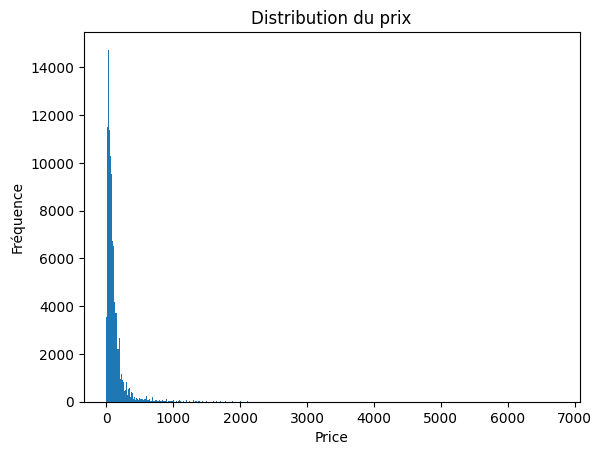

In [105]:
import matplotlib.pyplot as plt

plt.hist(df["price"], bins=500)
plt.xlabel("Price")
plt.ylabel("Fréquence")
plt.title("Distribution du prix")
plt.show()


In [106]:
df["product_category_name"].value_counts()


product_category_name
cama_mesa_banho                  11115
beleza_saude                      9670
esporte_lazer                     8641
moveis_decoracao                  8334
informatica_acessorios            7827
                                 ...  
la_cuisine                          14
cds_dvds_musicais                   14
pc_gamer                             9
fashion_roupa_infanto_juvenil        8
seguros_e_servicos                   2
Name: count, Length: 73, dtype: int64

In [107]:
df["product_category_name"].value_counts(normalize=True) * 100


product_category_name
cama_mesa_banho                  10.009275
beleza_saude                      8.708025
esporte_lazer                     7.781390
moveis_decoracao                  7.504930
informatica_acessorios            7.048367
                                   ...    
la_cuisine                        0.012607
cds_dvds_musicais                 0.012607
pc_gamer                          0.008105
fashion_roupa_infanto_juvenil     0.007204
seguros_e_servicos                0.001801
Name: proportion, Length: 73, dtype: float64

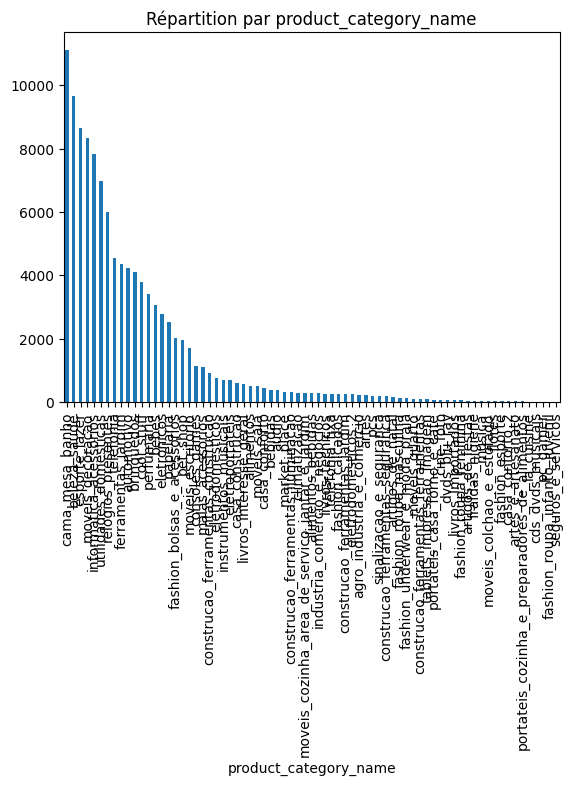

In [108]:
df["product_category_name"].value_counts().plot(kind="bar")
plt.title("Répartition par product_category_name")
plt.show()


In [118]:
sort_df_seller_city = df.sort_values(["seller_state"], ascending=True)

In [119]:
sort_df_seller_city.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,seller_zip_code_prefix,seller_city,seller_state,geolocation_lat_y,geolocation_lng_y,payment_installments,payment_value,payment_type_boleto,payment_type_credit_card,payment_type_other
34589,d3c8851a6651eeff2f73b0e011ac45d0,957f8e082185574de25992dc659ebbc0,processing,2016-10-05 22:44:13,2016-10-06 15:51:05,NaN,NaN,2016-12-09 00:00:00,07d5b1f9bdd053347f0213187b343ac9,3531,...,69900,rio branco,AC,-9.967843,-67.813284,0.0,299.84,0.0,1.0,0.0
22722,d573a47c29466bb2e4e46aef0ff04f23,d5efb94fdd7fe8e0ba70c7580088acae,delivered,2017-02-03 01:06:06,2017-02-03 01:15:11,2017-02-06 15:04:37,2017-05-05 00:09:56,2017-03-28 00:00:00,aaf7ed8313a90b1735dd28ab46546b30,57073,...,69005,manaus,AM,-3.131672,-60.019225,0.0,984.26,0.0,1.0,0.0
22721,ac1436b9efc2d8508c1abf9e4dca5709,9cae1ebde4a8d7f03a92da657abdb51c,delivered,2017-03-15 14:28:24,2017-03-15 14:28:24,2017-03-17 14:10:48,2017-04-07 15:23:01,2017-04-18 00:00:00,4d210caec5d9a335920c4a33e8afe467,33010,...,69005,manaus,AM,-3.131672,-60.019225,0.0,139.29,0.0,1.0,0.0
22720,686c0ba20be3837a5041edbc39d3f9ae,9d313f559eb6ce11ff81d6402f472763,delivered,2017-03-12 20:54:08,2017-03-12 20:54:08,2017-03-17 14:10:50,2017-04-11 09:27:57,2017-04-11 00:00:00,bb2f08afc6554dac6cad068e40145cbc,65200,...,69005,manaus,AM,-3.131672,-60.019225,0.0,135.25,0.0,1.0,0.0
37811,7737b48ac906ed0be3c192bb1fc4c4ef,710f79302fb4b836681bfd921167167b,invoiced,2018-08-07 09:48:08,2018-08-08 08:50:20,NaN,NaN,2018-08-14 00:00:00,42065396a8ea4eb85ed40b88ec739043,41195,...,42738,lauro de freitas,BA,-12.893167,-38.337875,0.0,180.32,0.0,1.0,0.0


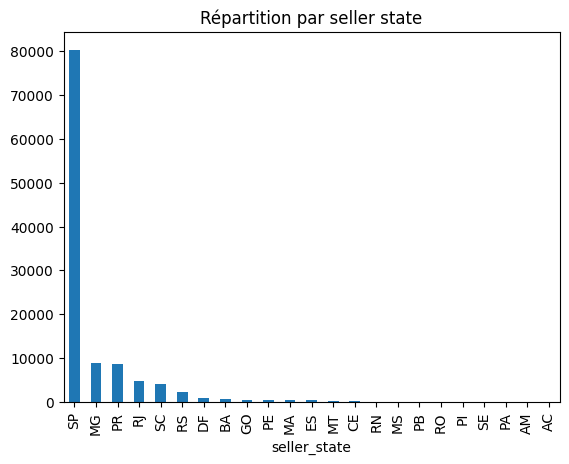

In [121]:
sort_df_seller_city["seller_state"].value_counts().plot(kind="bar")
plt.title("Répartition par seller state")
plt.show()


AttributeError: 'function' object has no attribute 'plot'

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 112647 entries, 0 to 112649
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112647 non-null  object 
 1   customer_id                    112647 non-null  object 
 2   order_status                   112647 non-null  object 
 3   order_purchase_timestamp       112647 non-null  object 
 4   order_approved_at              112632 non-null  object 
 5   order_delivered_carrier_date   111453 non-null  object 
 6   order_delivered_customer_date  110193 non-null  object 
 7   order_estimated_delivery_date  112647 non-null  object 
 8   customer_unique_id             112647 non-null  object 
 9   customer_zip_code_prefix       112647 non-null  int64  
 10  customer_city                  112647 non-null  object 
 11  customer_state                 112647 non-null  object 
 12  geolocation_lat_x              1123

In [ ]:
pd.set_option('display.max_rows')
pd.set_option('display.max_cols')

In [123]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,seller_zip_code_prefix,seller_city,seller_state,geolocation_lat_y,geolocation_lng_y,payment_installments,payment_value,payment_type_boleto,payment_type_credit_card,payment_type_other
0,7f39ba4c9052be115350065d07583cac,d7fc82cbeafea77bd0a8fbbf6296e387,delivered,2017-10-18 08:16:34,2017-10-18 23:56:20,2017-10-20 14:29:01,2017-10-27 16:46:05,2017-11-09 00:00:00,9de5797cddb92598755a0f76383ddbbb,35490,...,9080,santo andre,SP,-23.640444,-46.541742,0.0,916.02,0.0,1.0,0.0
1,9dc8d1a6f16f1b89874c29c9d8d30447,d9442164acf4b03109425633efaa0cfc,delivered,2017-10-12 13:33:22,2017-10-12 13:49:22,2017-10-17 15:42:42,2017-10-24 20:17:44,2017-11-06 00:00:00,9915eb9f74b6c11aaf04833f65b00e93,38600,...,9080,santo andre,SP,-23.640444,-46.541742,0.0,916.02,0.0,1.0,0.0
2,d455a8cb295653b55abda06d434ab492,944b72539d7e1f7f7fc6e46639ef1fe3,delivered,2017-09-26 22:17:05,2017-09-27 22:24:16,2017-09-29 15:53:03,2017-10-07 16:12:47,2017-10-30 00:00:00,3c7e305796add66698959fc7ad176f6b,87502,...,9080,santo andre,SP,-23.640444,-46.541742,0.0,916.02,0.0,1.0,0.0
3,006e43460a55bc60c0a437521e426529,23bfd4316e261786deed5a08231c75bc,delivered,2017-05-11 00:24:35,2017-05-11 01:30:22,2017-05-12 12:26:32,2017-05-19 09:51:17,2017-06-02 00:00:00,1df0a296f852bdf1a17b085730f4b894,11431,...,29156,cariacica,ES,-20.278513,-40.411675,0.0,142.06,0.0,1.0,0.0
4,00dfb074b5c910fbd08e04691c4b712f,a5ced4926d7d8fa71e9be2b007720356,delivered,2017-06-08 19:43:35,2017-06-08 19:55:19,2017-06-09 15:12:41,2017-06-15 09:03:59,2017-07-10 00:00:00,94ea9edee3656707894565f35cb8570d,8671,...,29156,cariacica,ES,-20.278513,-40.411675,0.0,134.57,0.0,1.0,0.0


## ANALYSE MULTIVARIÉE

In [124]:
df[["price", "payment_value"]].corr()


,price,payment_value
price,1.000000,0.761235
payment_value,0.761235,1.000000


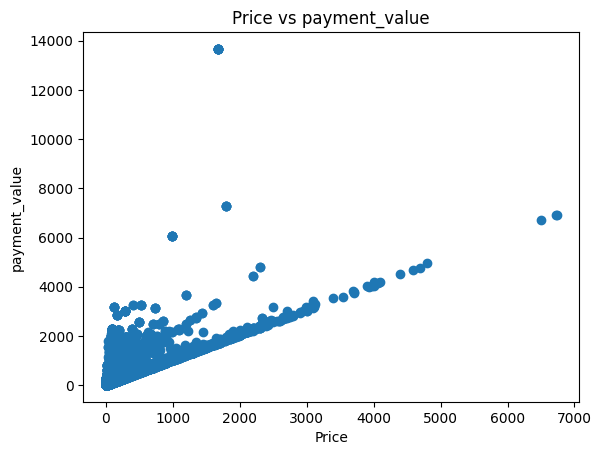

In [125]:
plt.scatter(df["price"], df["payment_value"])
plt.xlabel("Price")
plt.ylabel("payment_value")
plt.title("Price vs payment_value")
plt.show()


In [126]:
df.groupby("seller_state")["price"].mean()


seller_state
AC    267.000000
AM    392.333333
BA    444.108180
CE    215.325957
DF    108.731346
ES    128.197876
GO    127.690788
MA     89.898642
MG    114.598928
MS    171.033800
MT    117.729103
PA    154.750000
PB    449.868421
PE    204.227344
PI    210.166667
PR    145.564402
RJ    175.173147
RN    178.439286
RO    340.157143
RS    172.150769
SC    155.196582
SE    160.620000
SP    108.951684
Name: price, dtype: float64

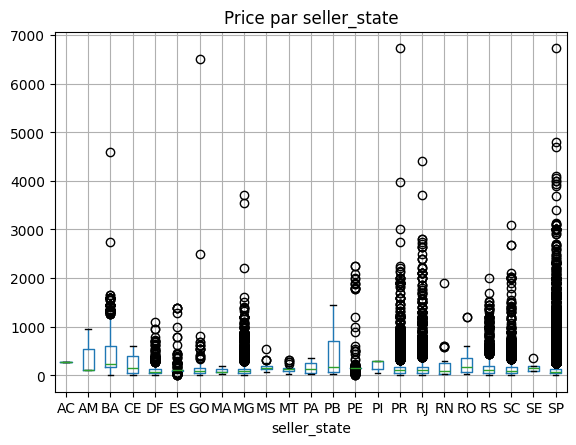

In [127]:
##Boxplot
df.boxplot(column="price", by="seller_state")
plt.title("Price par seller_state")
plt.suptitle("")
plt.show()


In [128]:
#Catégorielle ↔ Catégorielle
#Tableau croisé (cross-tab)

pd.crosstab(df["seller_state"], df["price"])


price,0.85,1.20,2.20,2.29,2.90,2.99,3.00,3.06,3.49,3.50,...,3999.90,4059.00,4099.99,4399.87,4590.00,4690.00,4799.00,6499.00,6729.00,6735.00
seller_state,,,,,,,,,,,,,,,,,,,,,
AC,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AM,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
CE,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DF,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ES,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GO,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
MA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
MG,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [129]:


pd.crosstab(df["product_category_name"], df["price"])

price,0.85,1.20,2.20,2.29,2.90,2.99,3.06,3.49,3.50,3.54,...,3999.90,4059.00,4099.99,4399.87,4590.00,4690.00,4799.00,6499.00,6729.00,6735.00
product_category_name,,,,,,,,,,,,,,,,,,,,,
agro_industria_e_comercio,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
alimentos,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
alimentos_bebidas,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
artes,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
artes_e_artesanato,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sinalizacao_e_seguranca,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
tablets_impressao_imagem,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
telefonia,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [130]:
#Version normalisée
pd.crosstab(df["product_category_name"], df["price"], normalize="index") * 100


price,0.85,1.20,2.20,2.29,2.90,2.99,3.06,3.49,3.50,3.54,...,3999.90,4059.00,4099.99,4399.87,4590.00,4690.00,4799.00,6499.00,6729.00,6735.00
product_category_name,,,,,,,,,,,,,,,,,,,,,
agro_industria_e_comercio,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000
alimentos,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000
alimentos_bebidas,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000
artes,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.478469,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.478469,0.0,0.00000
artes_e_artesanato,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sinalizacao_e_seguranca,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000
tablets_impressao_imagem,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000
telefonia,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000


## Analyse multivariée avancée

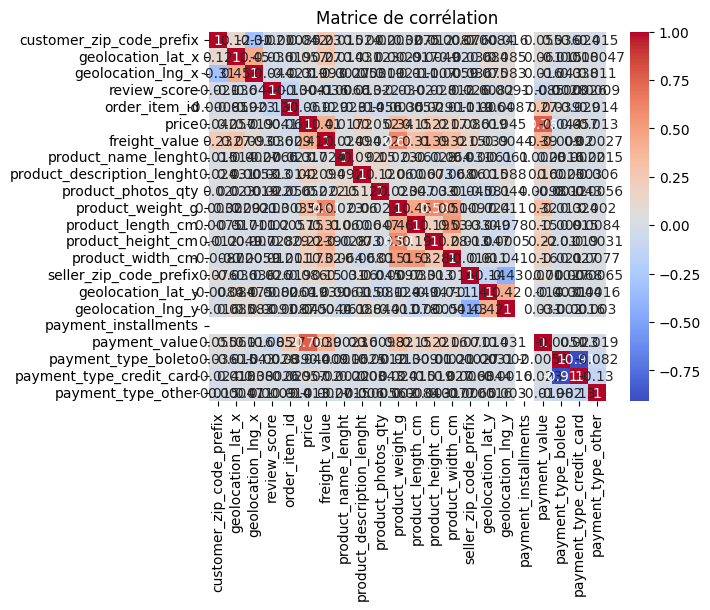

In [131]:
import seaborn as sns

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()


In [ ]:
## Score de fidélité moyen selon l’achat

#df.groupby("achat")["score_fidelite"].mean()


In [132]:
print("Nombre de lignes dans le dataset : ",len(df))
nan_values_col = pd.DataFrame({'colonne':df.isna().sum().index,'nbre de nan':df.isna().sum().values})
nan_values_col

Nombre de lignes dans le dataset :  112647


,colonne,nbre de nan
0,order_id,0
1,customer_id,0
2,order_status,0
3,order_purchase_timestamp,0
4,order_approved_at,15
5,order_delivered_carrier_date,1194
6,order_delivered_customer_date,2454
7,order_estimated_delivery_date,0
8,customer_unique_id,0
9,customer_zip_code_prefix,0


In [135]:
# On retire la commande qui ne contient pas d'information de prix
df = df[df['order_id'] != 'bfbd0f9bdef84302105ad712db648a6c']

## Exploration des dates

In [136]:
dfdate = df[['customer_id','order_status','order_purchase_timestamp','order_approved_at',
             'order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date']]
dfdate

,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,d7fc82cbeafea77bd0a8fbbf6296e387,delivered,2017-10-18 08:16:34,2017-10-18 23:56:20,2017-10-20 14:29:01,2017-10-27 16:46:05,2017-11-09 00:00:00
1,d9442164acf4b03109425633efaa0cfc,delivered,2017-10-12 13:33:22,2017-10-12 13:49:22,2017-10-17 15:42:42,2017-10-24 20:17:44,2017-11-06 00:00:00
2,944b72539d7e1f7f7fc6e46639ef1fe3,delivered,2017-09-26 22:17:05,2017-09-27 22:24:16,2017-09-29 15:53:03,2017-10-07 16:12:47,2017-10-30 00:00:00
3,23bfd4316e261786deed5a08231c75bc,delivered,2017-05-11 00:24:35,2017-05-11 01:30:22,2017-05-12 12:26:32,2017-05-19 09:51:17,2017-06-02 00:00:00
4,a5ced4926d7d8fa71e9be2b007720356,delivered,2017-06-08 19:43:35,2017-06-08 19:55:19,2017-06-09 15:12:41,2017-06-15 09:03:59,2017-07-10 00:00:00
...,...,...,...,...,...,...,...
112645,c14683c13fb7e9f39e4228f207eb05a8,canceled,2017-03-13 20:30:13,2017-03-13 20:30:13,NaN,NaN,2017-04-03 00:00:00
112646,a75a82a30eac1c78ee2382e13027c787,processing,2017-03-13 13:32:46,2017-03-13 13:32:46,NaN,NaN,2017-04-13 00:00:00
112647,04d7d73089b39d83f81b829cbd98e43d,processing,2017-03-15 10:30:17,2017-03-15 10:30:17,NaN,NaN,2017-04-13 00:00:00
112648,e97a76910029690bc1f5b67376c38af5,delivered,2017-01-19 21:48:41,2017-01-19 22:01:56,2017-01-25 16:05:15,2017-01-30 11:41:52,2017-03-15 00:00:00


In [137]:
df['order_status'].unique()

array(['delivered', 'shipped', 'canceled', 'processing', 'invoiced',
       'unavailable', 'approved'], dtype=object)

In [138]:
dfdate.groupby(by='order_status').count()

,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
order_status,,,,,,
approved,3,3,3,0,0,3
canceled,542,542,542,76,7,542
delivered,110194,110194,110179,110192,110186,110194
invoiced,359,359,359,0,0,359
processing,357,357,357,0,0,357
shipped,1185,1185,1185,1185,0,1185
unavailable,7,7,7,0,0,7


Pour la suite on se concentre sur les commandes terminées (statut = delivered)

In [139]:
df = df.loc[df['order_status'] == 'delivered']

In [140]:
df.shape

(110194, 39)

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110194 entries, 0 to 112649
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       110194 non-null  object 
 1   customer_id                    110194 non-null  object 
 2   order_status                   110194 non-null  object 
 3   order_purchase_timestamp       110194 non-null  object 
 4   order_approved_at              110179 non-null  object 
 5   order_delivered_carrier_date   110192 non-null  object 
 6   order_delivered_customer_date  110186 non-null  object 
 7   order_estimated_delivery_date  110194 non-null  object 
 8   customer_unique_id             110194 non-null  object 
 9   customer_zip_code_prefix       110194 non-null  int64  
 10  customer_city                  110194 non-null  object 
 11  customer_state                 110194 non-null  object 
 12  geolocation_lat_x              1099

In [142]:
#On crée la variable de temps de livraison (nbre de jour entre la commande et la livraison) et la différence entre la date
#de livraison estimée et la date de livraison réelles

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])


df['order_time'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['diff_estimated_real'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

df['delay'] =  np.where(df['diff_estimated_real'] > 0, 1 , 0)

In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110194 entries, 0 to 112649
Data columns (total 42 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110194 non-null  object        
 1   customer_id                    110194 non-null  object        
 2   order_status                   110194 non-null  object        
 3   order_purchase_timestamp       110194 non-null  datetime64[ns]
 4   order_approved_at              110179 non-null  object        
 5   order_delivered_carrier_date   110192 non-null  object        
 6   order_delivered_customer_date  110186 non-null  datetime64[ns]
 7   order_estimated_delivery_date  110194 non-null  datetime64[ns]
 8   customer_unique_id             110194 non-null  object        
 9   customer_zip_code_prefix       110194 non-null  int64         
 10  customer_city                  110194 non-null  object        
 11  custo

## PCA sur une sélection de variables quantitatives

In [145]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,geolocation_lat_y,geolocation_lng_y,payment_installments,payment_value,payment_type_boleto,payment_type_credit_card,payment_type_other,order_time,diff_estimated_real,delay
0,7f39ba4c9052be115350065d07583cac,d7fc82cbeafea77bd0a8fbbf6296e387,delivered,2017-10-18 08:16:34,2017-10-18 23:56:20,2017-10-20 14:29:01,2017-10-27 16:46:05,2017-11-09,9de5797cddb92598755a0f76383ddbbb,35490,...,-23.640444,-46.541742,0.0,916.02,0.0,1.0,0.0,9.0,-13.0,0
1,9dc8d1a6f16f1b89874c29c9d8d30447,d9442164acf4b03109425633efaa0cfc,delivered,2017-10-12 13:33:22,2017-10-12 13:49:22,2017-10-17 15:42:42,2017-10-24 20:17:44,2017-11-06,9915eb9f74b6c11aaf04833f65b00e93,38600,...,-23.640444,-46.541742,0.0,916.02,0.0,1.0,0.0,12.0,-13.0,0
2,d455a8cb295653b55abda06d434ab492,944b72539d7e1f7f7fc6e46639ef1fe3,delivered,2017-09-26 22:17:05,2017-09-27 22:24:16,2017-09-29 15:53:03,2017-10-07 16:12:47,2017-10-30,3c7e305796add66698959fc7ad176f6b,87502,...,-23.640444,-46.541742,0.0,916.02,0.0,1.0,0.0,10.0,-23.0,0
3,006e43460a55bc60c0a437521e426529,23bfd4316e261786deed5a08231c75bc,delivered,2017-05-11 00:24:35,2017-05-11 01:30:22,2017-05-12 12:26:32,2017-05-19 09:51:17,2017-06-02,1df0a296f852bdf1a17b085730f4b894,11431,...,-20.278513,-40.411675,0.0,142.06,0.0,1.0,0.0,8.0,-14.0,0
4,00dfb074b5c910fbd08e04691c4b712f,a5ced4926d7d8fa71e9be2b007720356,delivered,2017-06-08 19:43:35,2017-06-08 19:55:19,2017-06-09 15:12:41,2017-06-15 09:03:59,2017-07-10,94ea9edee3656707894565f35cb8570d,8671,...,-20.278513,-40.411675,0.0,134.57,0.0,1.0,0.0,6.0,-25.0,0


In [146]:
df.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_carrier_date             object
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_city                            object
customer_state                           object
geolocation_lat_x                       float64
geolocation_lng_x                       float64
review_score                            float64
order_item_id                             int64
product_id                               object
seller_id                                object
shipping_limit_date                      object
price                                   float64
freight_value                           

In [147]:
dfpca = df[['geolocation_lat_x','geolocation_lng_x','review_score','price','freight_value',
            'payment_value','payment_installments','payment_type_boleto','payment_type_credit_card','payment_type_other',
           'order_time','diff_estimated_real']]

In [148]:
dfpca.head()

,geolocation_lat_x,geolocation_lng_x,review_score,price,freight_value,payment_value,payment_installments,payment_type_boleto,payment_type_credit_card,payment_type_other,order_time,diff_estimated_real
0,-20.671105,-44.065872,1.0,895.0,21.02,916.02,0.0,0.0,1.0,0.0,9.0,-13.0
1,-17.224179,-46.874265,5.0,895.0,21.02,916.02,0.0,0.0,1.0,0.0,12.0,-13.0
2,-23.759416,-53.292784,5.0,895.0,21.02,916.02,0.0,0.0,1.0,0.0,10.0,-23.0
3,-23.995826,-46.278739,5.0,99.0,43.06,142.06,0.0,0.0,1.0,0.0,8.0,-14.0
4,-23.544640,-46.326946,5.0,99.5,35.07,134.57,0.0,0.0,1.0,0.0,6.0,-25.0


In [149]:
print("Nombre de lignes dans le dataset : ",len(dfpca))
nan_values_col = pd.DataFrame({'colonne':dfpca.isna().sum().index,'nbre de nan':dfpca.isna().sum().values})
nan_values_col

Nombre de lignes dans le dataset :  110194


,colonne,nbre de nan
0,geolocation_lat_x,288
1,geolocation_lng_x,288
2,review_score,827
3,price,0
4,freight_value,0
5,payment_value,0
6,payment_installments,0
7,payment_type_boleto,0
8,payment_type_credit_card,0
9,payment_type_other,0


In [150]:
dfpca = dfpca.dropna()
dfpca.shape

(109072, 12)

In [151]:
def display_circles(pcs, n_comp, pca, axis_ranks, labels=None, label_rotation=0, lims=None):
    for d1, d2 in axis_ranks: # On affiche les 3 premiers plans factoriels, donc les 6 premières composantes
        if d2 < n_comp:

            # initialisation de la figure
            fig, ax = plt.subplots(figsize=(10,10))

            # détermination des limites du graphique
            if lims is not None :
                xmin, xmax, ymin, ymax = lims
            elif pcs.shape[1] < 30 :
                xmin, xmax, ymin, ymax = -1, 1, -1, 1
            else :
                xmin, xmax, ymin, ymax = min(pcs[d1,:]), max(pcs[d1,:]), min(pcs[d2,:]), max(pcs[d2,:])

            # affichage des flèches
            # s'il y a plus de 30 flèches, on n'affiche pas le triangle à leur extrémité
            if pcs.shape[1] < 30 :
                plt.quiver(np.zeros(pcs.shape[1]), np.zeros(pcs.shape[1]),
                   pcs[d1,:], pcs[d2,:], 
                   angles='xy', scale_units='xy', scale=1, color="grey")
                # (voir la doc : https://matplotlib.org/api/_as_gen/matplotlib.pyplot.quiver.html)
            else:
                lines = [[[0,0],[x,y]] for x,y in pcs[[d1,d2]].T]
                ax.add_collection(LineCollection(lines, axes=ax, alpha=.1, color='black'))
            
            # affichage des noms des variables  
            if labels is not None:  
                for i,(x, y) in enumerate(pcs[[d1,d2]].T):
                    if x >= xmin and x <= xmax and y >= ymin and y <= ymax :
                        plt.text(x, y, labels[i], fontsize='14', ha='left', va='center', rotation=label_rotation,
                                 color="blue", alpha=0.5)
            
            # affichage du cercle
            circle = plt.Circle((0,0), 1, facecolor='none', edgecolor='b')
            plt.gca().add_artist(circle)

            # définition des limites du graphique
            plt.xlim(xmin, xmax)
            plt.ylim(ymin, ymax)
        
            # affichage des lignes horizontales et verticales
            plt.plot([-1, 1], [0, 0], color='grey', ls='--')
            plt.plot([0, 0], [-1, 1], color='grey', ls='--')

            # nom des axes, avec le pourcentage d'inertie expliqué
            plt.xlabel('F{} ({}%)'.format(d1+1, round(100*pca.explained_variance_ratio_[d1],1)))
            plt.ylabel('F{} ({}%)'.format(d2+1, round(100*pca.explained_variance_ratio_[d2],1)))

            plt.title("Cercle des corrélations (F{} et F{})".format(d1+1, d2+1))
            plt.show(block=False)
        
def display_factorial_planes(X_projected, n_comp, pca, axis_ranks, labels=None, alpha=1, illustrative_var=None):
    for d1,d2 in axis_ranks:
        if d2 < n_comp:
 
            # initialisation de la figure       
            fig = plt.figure(figsize=(10,10))
        
            # affichage des points
            if illustrative_var is None:
                plt.scatter(X_projected[:, d1], X_projected[:, d2], alpha=alpha)
            else:
                illustrative_var = np.array(illustrative_var)
                for value in np.unique(illustrative_var):
                    selected = np.where(illustrative_var == value)
                    plt.scatter(X_projected[selected, d1], X_projected[selected, d2], alpha=alpha, label=value)
                plt.legend()

            # affichage des labels des points
            if labels is not None:
                for i,(x,y) in enumerate(X_projected[:,[d1,d2]]):
                    plt.text(x, y, labels[i],
                              fontsize='14', ha='center',va='center') 
                
            # détermination des limites du graphique
            boundary = np.max(np.abs(X_projected[:, [d1,d2]])) * 1.1
            plt.xlim([-boundary,boundary])
            plt.ylim([-boundary,boundary])
        
            # affichage des lignes horizontales et verticales
            plt.plot([-100, 100], [0, 0], color='grey', ls='--')
            plt.plot([0, 0], [-100, 100], color='grey', ls='--')

            # nom des axes, avec le pourcentage d'inertie expliqué
            plt.xlabel('F{} ({}%)'.format(d1+1, round(100*pca.explained_variance_ratio_[d1],1)))
            plt.ylabel('F{} ({}%)'.format(d2+1, round(100*pca.explained_variance_ratio_[d2],1)))

            plt.title("Projection des individus (sur F{} et F{})".format(d1+1, d2+1))
            plt.show(block=False)

def display_scree_plot(pca):
    plt.figure(figsize=(10,10))
    scree = pca.explained_variance_ratio_*100
    plt.bar(np.arange(len(scree))+1, scree)
    plt.plot(np.arange(len(scree))+1, scree.cumsum(),c="red",marker='o')
    plt.xlabel("rang de l'axe d'inertie")
    plt.ylabel("pourcentage d'inertie")
    plt.title("Eboulis des valeurs propres")
    plt.show(block=False)

<Figure size 1600x800 with 0 Axes>

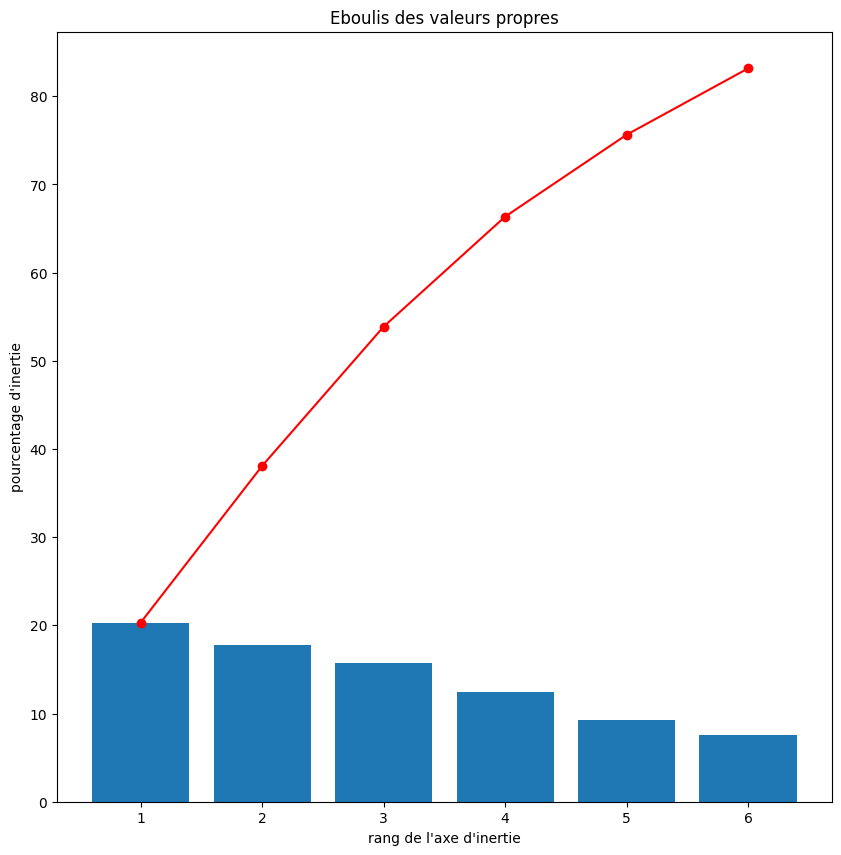

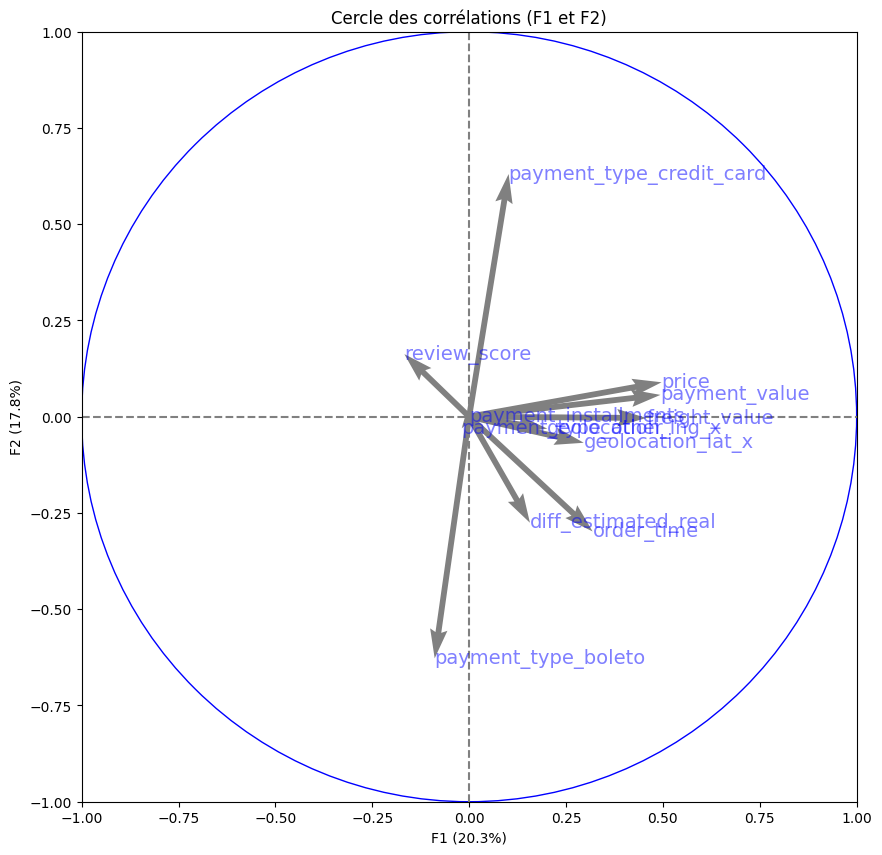

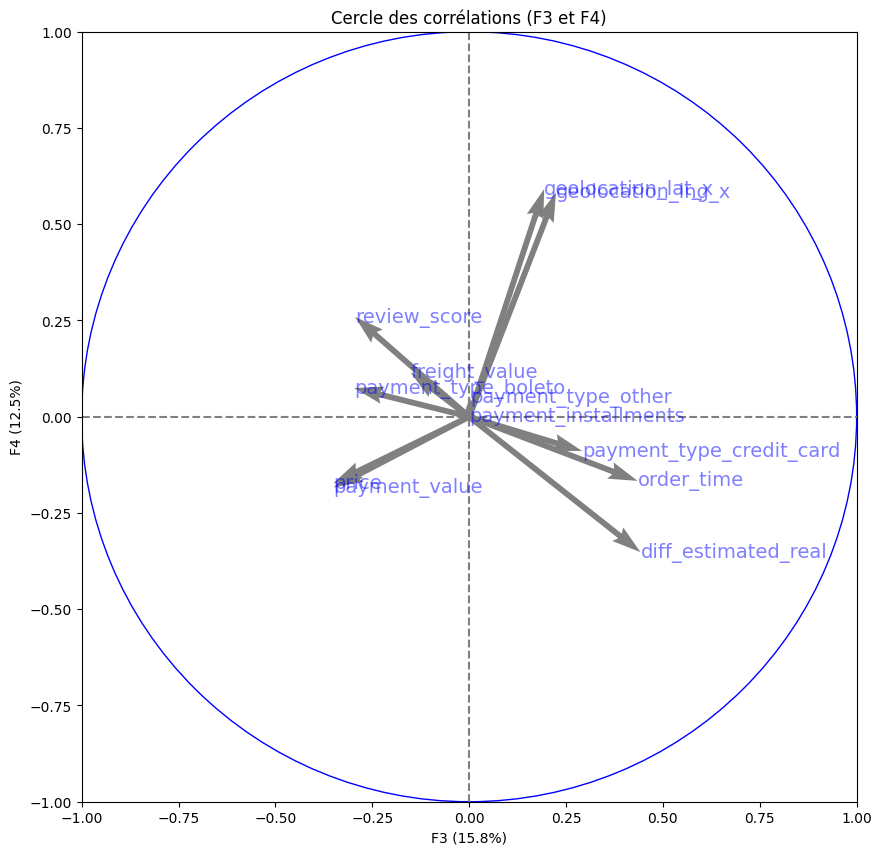

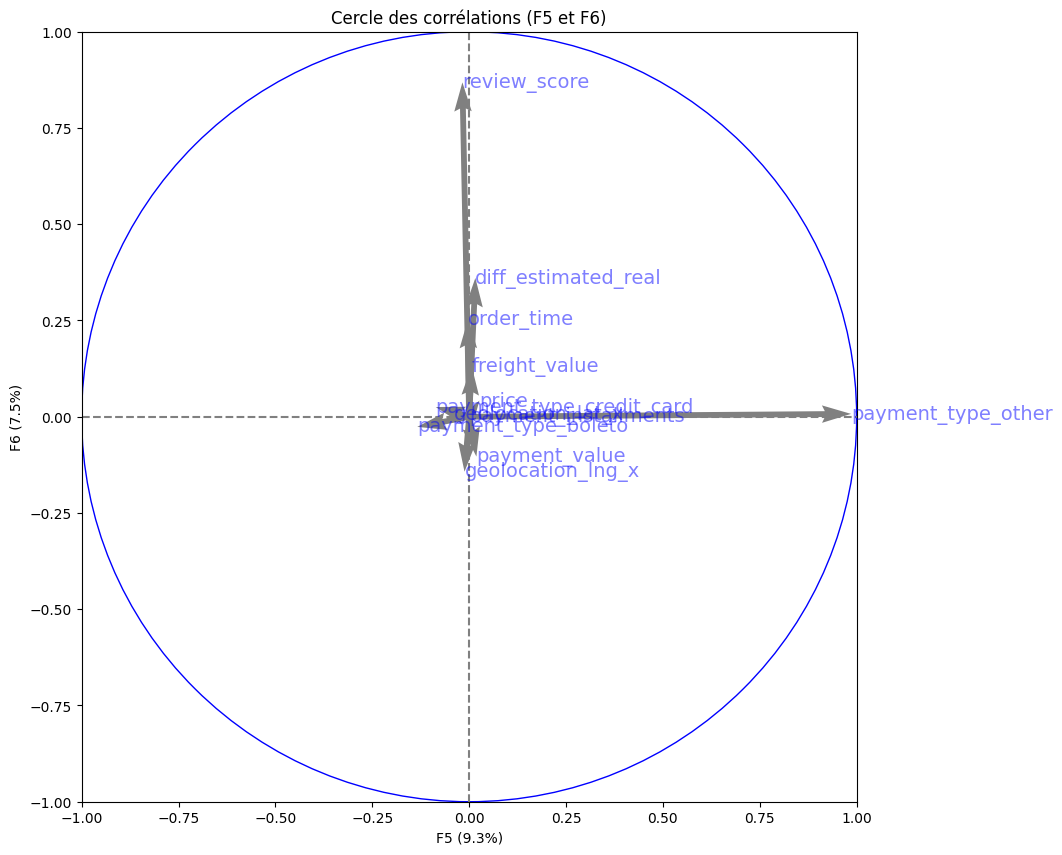

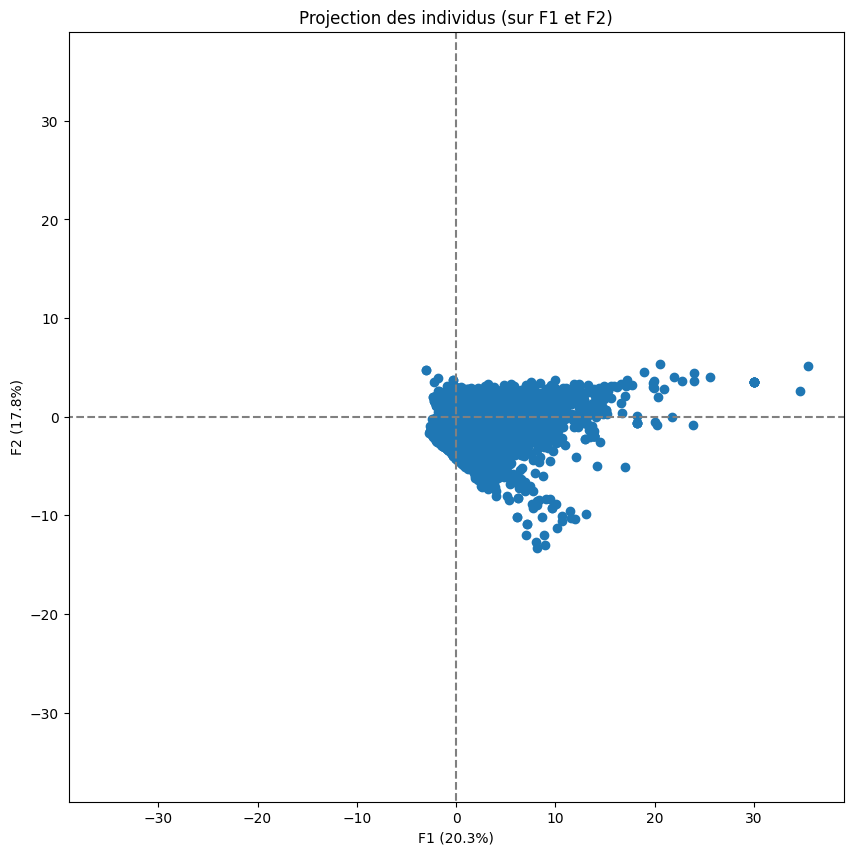

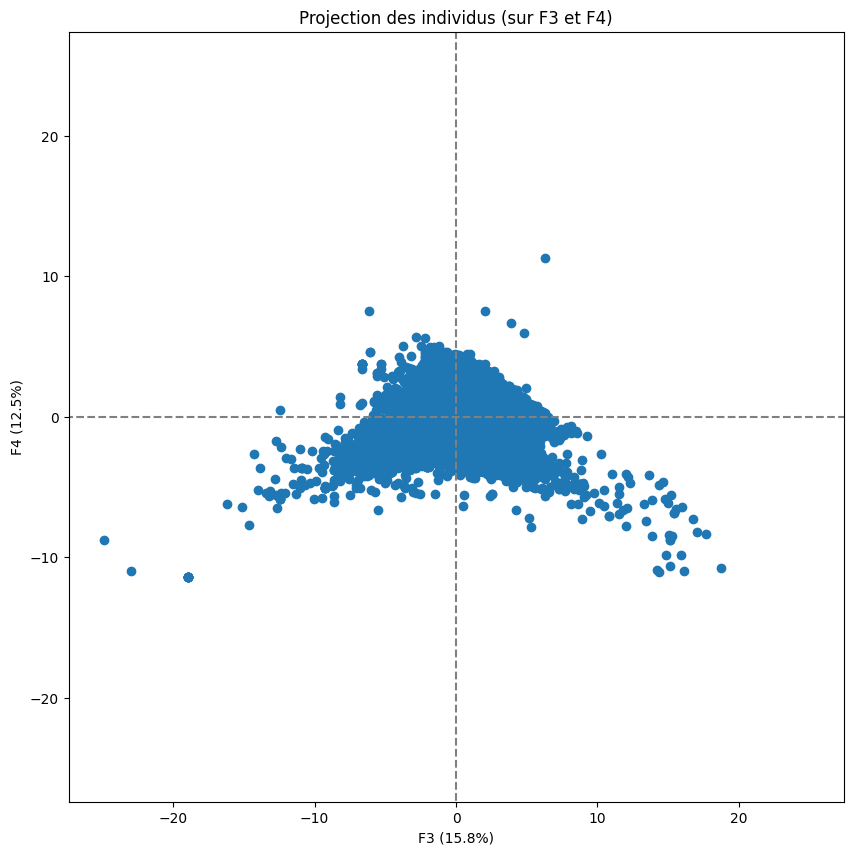

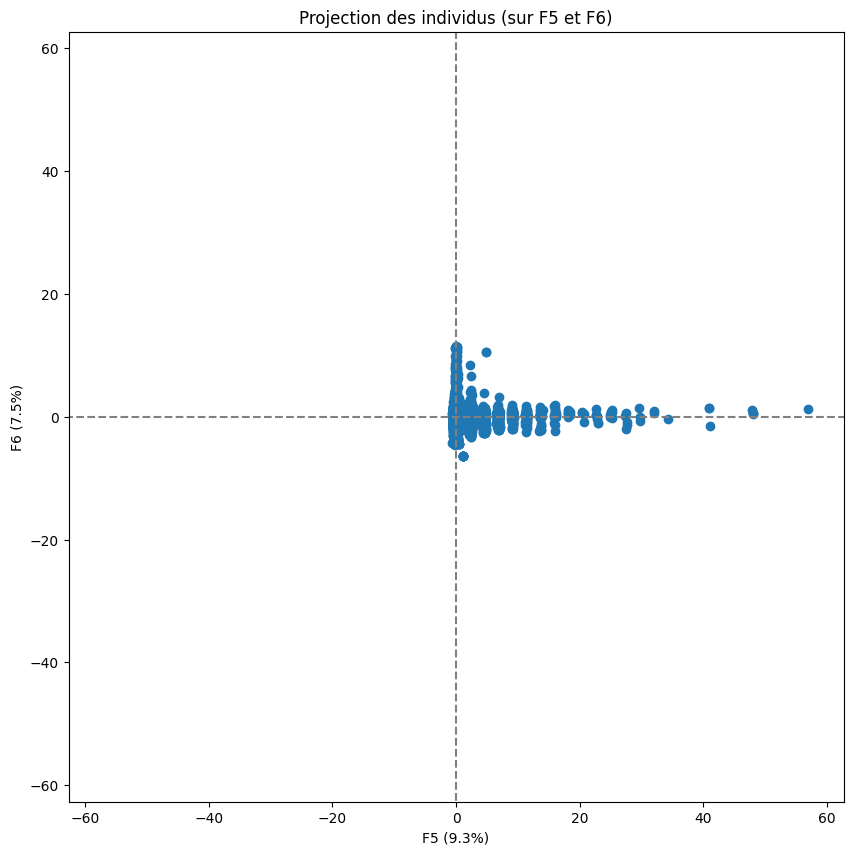

In [157]:
# Centrage et Réduction
std_scale = StandardScaler().fit(dfpca)
dfpca_scaled = std_scale.transform(dfpca)
n_comp = 6
features = dfpca.columns
# Calcul des composantes principales
pca = decomposition.PCA(n_components=n_comp)
pca.fit(dfpca_scaled)

plt.figure(figsize=(16,8))
# Eboulis des valeurs propres
display_scree_plot(pca)

# Cercle des corrélations
pcs = pca.components_
display_circles(pcs, n_comp, pca, [(0,1),(2,3),(4,5)], labels = np.array(features))

# Projection des individus
X_projected = pca.transform(dfpca_scaled)
display_factorial_planes(X_projected, n_comp, pca, [(0,1),(2,3),(4,5)])

plt.show()

# Clustering sur données RFM

## Création des variables RFM

Les colonnes RFM pour la segmentation marketing des clients : La segmentation RFM prend en compte la Récence (date de la dernière commande), la Fréquence des commandes et le Montant (de la dernière commande ou sur une période donnée) pour établir des segments de clients homogènes.

In [158]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,geolocation_lat_y,geolocation_lng_y,payment_installments,payment_value,payment_type_boleto,payment_type_credit_card,payment_type_other,order_time,diff_estimated_real,delay
0,7f39ba4c9052be115350065d07583cac,d7fc82cbeafea77bd0a8fbbf6296e387,delivered,2017-10-18 08:16:34,2017-10-18 23:56:20,2017-10-20 14:29:01,2017-10-27 16:46:05,2017-11-09,9de5797cddb92598755a0f76383ddbbb,35490,...,-23.640444,-46.541742,0.0,916.02,0.0,1.0,0.0,9.0,-13.0,0
1,9dc8d1a6f16f1b89874c29c9d8d30447,d9442164acf4b03109425633efaa0cfc,delivered,2017-10-12 13:33:22,2017-10-12 13:49:22,2017-10-17 15:42:42,2017-10-24 20:17:44,2017-11-06,9915eb9f74b6c11aaf04833f65b00e93,38600,...,-23.640444,-46.541742,0.0,916.02,0.0,1.0,0.0,12.0,-13.0,0
2,d455a8cb295653b55abda06d434ab492,944b72539d7e1f7f7fc6e46639ef1fe3,delivered,2017-09-26 22:17:05,2017-09-27 22:24:16,2017-09-29 15:53:03,2017-10-07 16:12:47,2017-10-30,3c7e305796add66698959fc7ad176f6b,87502,...,-23.640444,-46.541742,0.0,916.02,0.0,1.0,0.0,10.0,-23.0,0
3,006e43460a55bc60c0a437521e426529,23bfd4316e261786deed5a08231c75bc,delivered,2017-05-11 00:24:35,2017-05-11 01:30:22,2017-05-12 12:26:32,2017-05-19 09:51:17,2017-06-02,1df0a296f852bdf1a17b085730f4b894,11431,...,-20.278513,-40.411675,0.0,142.06,0.0,1.0,0.0,8.0,-14.0,0
4,00dfb074b5c910fbd08e04691c4b712f,a5ced4926d7d8fa71e9be2b007720356,delivered,2017-06-08 19:43:35,2017-06-08 19:55:19,2017-06-09 15:12:41,2017-06-15 09:03:59,2017-07-10,94ea9edee3656707894565f35cb8570d,8671,...,-20.278513,-40.411675,0.0,134.57,0.0,1.0,0.0,6.0,-25.0,0


In [159]:
rfm = df[['customer_unique_id','order_id','order_purchase_timestamp','payment_value']]
rfm

,customer_unique_id,order_id,order_purchase_timestamp,payment_value
0,9de5797cddb92598755a0f76383ddbbb,7f39ba4c9052be115350065d07583cac,2017-10-18 08:16:34,916.02
1,9915eb9f74b6c11aaf04833f65b00e93,9dc8d1a6f16f1b89874c29c9d8d30447,2017-10-12 13:33:22,916.02
2,3c7e305796add66698959fc7ad176f6b,d455a8cb295653b55abda06d434ab492,2017-09-26 22:17:05,916.02
3,1df0a296f852bdf1a17b085730f4b894,006e43460a55bc60c0a437521e426529,2017-05-11 00:24:35,142.06
4,94ea9edee3656707894565f35cb8570d,00dfb074b5c910fbd08e04691c4b712f,2017-06-08 19:43:35,134.57
...,...,...,...,...
112638,4182d20f129b3679e6808317f1e95567,7ab9c55c59eaeea579d047e2d8aaed81,2017-01-22 13:04:20,22.46
112639,f992b70fb02cdfadc277f493997515b7,81251f18621a822ad5b09593dfee4fc9,2017-01-21 14:17:21,22.46
112642,f3e9410701ce24f2956a79c7475ab834,94b35c9542f07ad80b3367f9051b63af,2017-01-24 12:38:48,74.11
112648,051bc94e9cd865806bba8eeefb336d0a,df537c849af44beef86a7ef7de12126a,2017-01-19 21:48:41,40.36


In [160]:
rfm.dtypes

customer_unique_id                  object
order_id                            object
order_purchase_timestamp    datetime64[ns]
payment_value                      float64
dtype: object

In [161]:
rfm['order_purchase_timestamp'] = pd.to_datetime(rfm['order_purchase_timestamp'])

# On positionne le projet à la fin de l'année 2018 et on calcule le nombre de jours depuis la dernière commande
rfm['Days_since_last_order'] = (pd.to_datetime('2018-12-31 23:59:59') - rfm['order_purchase_timestamp']).dt.days

/var/folders/x0/ydjqlz4d3sg5mw1p32prqlh80000gn/T/ipykernel_7777/455165005.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm['order_purchase_timestamp'] = pd.to_datetime(rfm['order_purchase_timestamp'])
/var/folders/x0/ydjqlz4d3sg5mw1p32prqlh80000gn/T/ipykernel_7777/455165005.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm['Days_since_last_order'] = (pd.to_datetime('2018-12-31 23:59:59') - rfm['order_purchase_timestamp']).dt.days


In [162]:
rfm

,customer_unique_id,order_id,order_purchase_timestamp,payment_value,Days_since_last_order
0,9de5797cddb92598755a0f76383ddbbb,7f39ba4c9052be115350065d07583cac,2017-10-18 08:16:34,916.02,439
1,9915eb9f74b6c11aaf04833f65b00e93,9dc8d1a6f16f1b89874c29c9d8d30447,2017-10-12 13:33:22,916.02,445
2,3c7e305796add66698959fc7ad176f6b,d455a8cb295653b55abda06d434ab492,2017-09-26 22:17:05,916.02,461
3,1df0a296f852bdf1a17b085730f4b894,006e43460a55bc60c0a437521e426529,2017-05-11 00:24:35,142.06,599
4,94ea9edee3656707894565f35cb8570d,00dfb074b5c910fbd08e04691c4b712f,2017-06-08 19:43:35,134.57,571
...,...,...,...,...,...
112638,4182d20f129b3679e6808317f1e95567,7ab9c55c59eaeea579d047e2d8aaed81,2017-01-22 13:04:20,22.46,708
112639,f992b70fb02cdfadc277f493997515b7,81251f18621a822ad5b09593dfee4fc9,2017-01-21 14:17:21,22.46,709
112642,f3e9410701ce24f2956a79c7475ab834,94b35c9542f07ad80b3367f9051b63af,2017-01-24 12:38:48,74.11,706
112648,051bc94e9cd865806bba8eeefb336d0a,df537c849af44beef86a7ef7de12126a,2017-01-19 21:48:41,40.36,711


In [163]:
len(rfm['customer_unique_id'].unique())

93357

In [164]:
# Calcul du nombre de commandes effectuées et panier moyen
freq_panier = rfm.groupby("customer_unique_id").agg({"Days_since_last_order": "nunique",
                                                    'payment_value': "mean"}).reset_index()
freq_panier = freq_panier.sort_values(by='Days_since_last_order').rename(columns={"Days_since_last_order": "Frequence_achat",
                                                                                 "payment_value": "Panier_moyen"})
freq_panier

,customer_unique_id,Frequence_achat,Panier_moyen
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.900000
61924,a9a31f6600f5bb46793e66f85f382bf4,1,104.840000
61923,a9a01f767af5be3c3666cf307d5f790f,1,22.290000
61922,a99e3f897f5244cc9e9491a608daf32a,1,61.980000
61921,a99dd2ba0951dc3f14450042d8969456,1,210.600000
...,...,...,...
36706,6469f99c1f9dfae7733b25662e7f1782,6,108.121111
80537,dc813062e0fc23409cd255f7f53c7074,6,246.406364
73920,ca77025e7201e3b30c44b472ff346268,7,177.203333
10060,1b6c7548a2a1f9037c1fd3ddfed95f33,7,154.060000


In [165]:
rfm = rfm.merge(freq_panier, how = 'left', on ='customer_unique_id')
rfm

,customer_unique_id,order_id,order_purchase_timestamp,payment_value,Days_since_last_order,Frequence_achat,Panier_moyen
0,9de5797cddb92598755a0f76383ddbbb,7f39ba4c9052be115350065d07583cac,2017-10-18 08:16:34,916.02,439,1,916.02
1,9915eb9f74b6c11aaf04833f65b00e93,9dc8d1a6f16f1b89874c29c9d8d30447,2017-10-12 13:33:22,916.02,445,1,916.02
2,3c7e305796add66698959fc7ad176f6b,d455a8cb295653b55abda06d434ab492,2017-09-26 22:17:05,916.02,461,1,916.02
3,1df0a296f852bdf1a17b085730f4b894,006e43460a55bc60c0a437521e426529,2017-05-11 00:24:35,142.06,599,1,142.06
4,94ea9edee3656707894565f35cb8570d,00dfb074b5c910fbd08e04691c4b712f,2017-06-08 19:43:35,134.57,571,1,134.57
...,...,...,...,...,...,...,...
110189,4182d20f129b3679e6808317f1e95567,7ab9c55c59eaeea579d047e2d8aaed81,2017-01-22 13:04:20,22.46,708,1,22.46
110190,f992b70fb02cdfadc277f493997515b7,81251f18621a822ad5b09593dfee4fc9,2017-01-21 14:17:21,22.46,709,1,22.46
110191,f3e9410701ce24f2956a79c7475ab834,94b35c9542f07ad80b3367f9051b63af,2017-01-24 12:38:48,74.11,706,1,74.11
110192,051bc94e9cd865806bba8eeefb336d0a,df537c849af44beef86a7ef7de12126a,2017-01-19 21:48:41,40.36,711,1,40.36


In [166]:
print("Nombre de lignes dans le dataset : ",len(rfm))
nanrfm = pd.DataFrame({'colonne':rfm.isna().sum().index,'nbre de nan':rfm.isna().sum().values})
nanrfm

Nombre de lignes dans le dataset :  110194


,colonne,nbre de nan
0,customer_unique_id,0
1,order_id,0
2,order_purchase_timestamp,0
3,payment_value,0
4,Days_since_last_order,0
5,Frequence_achat,0
6,Panier_moyen,0


In [167]:
# On ne conserve que la dernière commande en date 
rfm = rfm.sort_values('Days_since_last_order').drop_duplicates(subset='customer_unique_id', keep='first')
rfm = rfm.reset_index()
rfm = rfm[['Days_since_last_order','Frequence_achat','Panier_moyen']]
rfm

,Days_since_last_order,Frequence_achat,Panier_moyen
0,124,1,106.95
1,124,1,497.25
2,124,1,33.23
3,124,1,73.10
4,124,1,14.29
...,...,...,...
93352,819,1,53.73
93353,819,1,39.09
93354,819,1,154.57
93355,819,1,40.95


In [168]:
rfm.dtypes

Days_since_last_order      int64
Frequence_achat            int64
Panier_moyen             float64
dtype: object

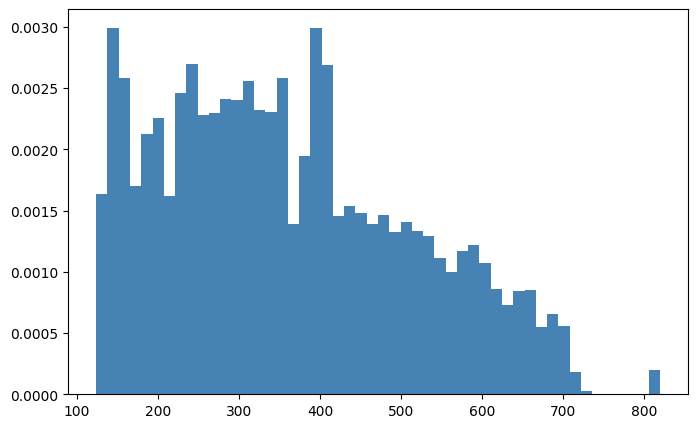

In [169]:
plt.figure(figsize=(8,5))
plt.hist(rfm['Days_since_last_order'], bins=50, color='steelblue', density=True, edgecolor='none')
plt.show()

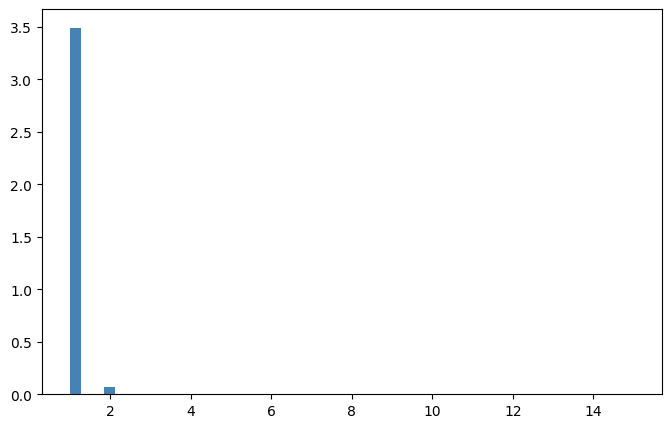

In [170]:
plt.figure(figsize=(8,5))
plt.hist(rfm['Frequence_achat'], bins=50, color='steelblue', density=True, edgecolor='none')
plt.show()

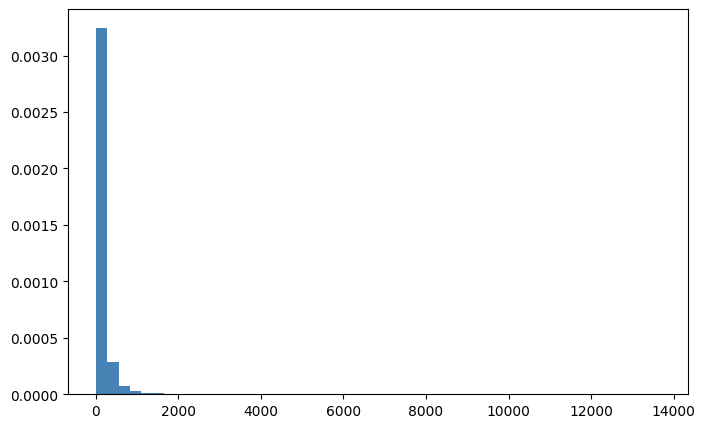

In [171]:
plt.figure(figsize=(8,5))
plt.hist(rfm['Panier_moyen'], bins=50, color='steelblue', density=True, edgecolor='none')
plt.show()

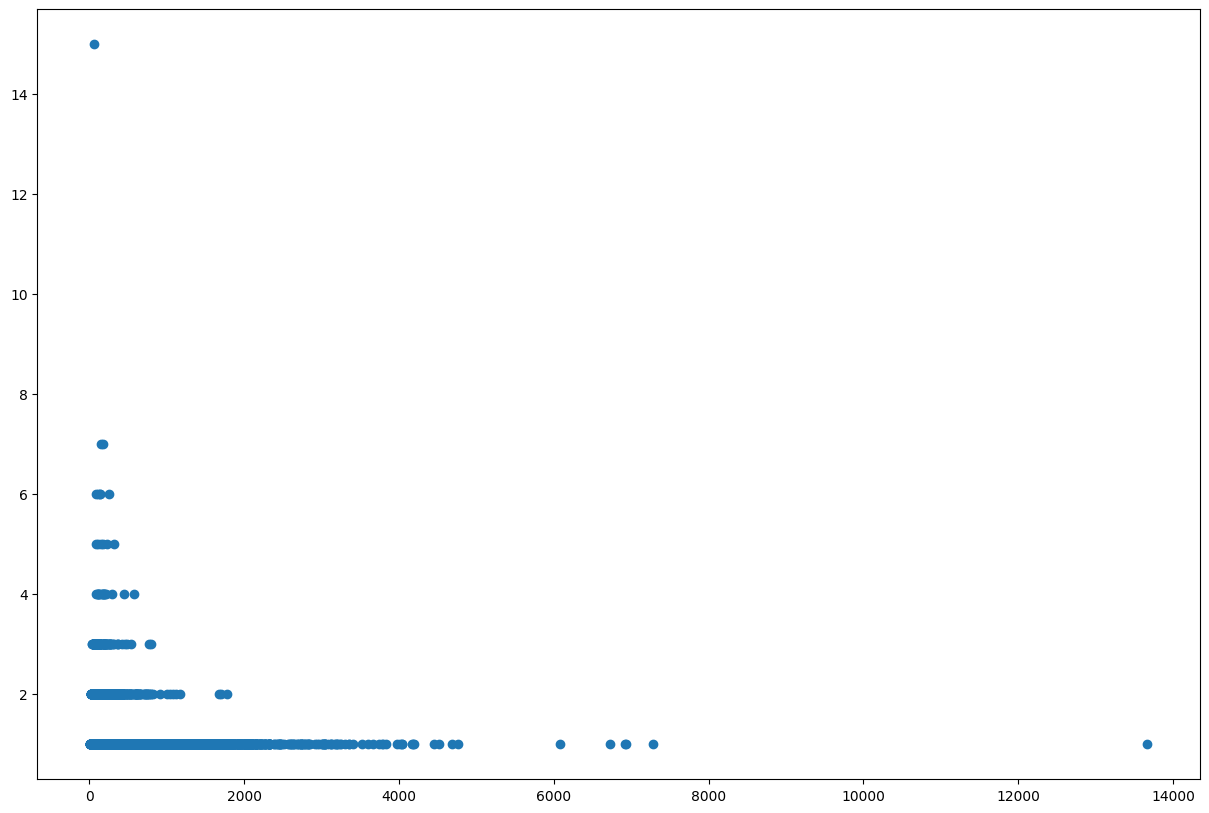

In [172]:
plt.figure(figsize=(15,10))
plt.scatter(rfm['Panier_moyen'], rfm['Frequence_achat'])

In [173]:
rfm.describe()

,Days_since_last_order,Frequence_achat,Panier_moyen
count,93357.000000,93357.000000,93357.000000
mean,361.473783,1.023887,160.450078
std,152.587935,0.177241,219.725771
min,124.000000,1.000000,9.590000
25%,238.000000,1.000000,62.390000
50%,342.000000,1.000000,105.700000
75%,470.000000,1.000000,176.760000
max,819.000000,15.000000,13664.080000


In [174]:
rfm.loc[rfm['Frequence_achat']==15]

,Days_since_last_order,Frequence_achat,Panier_moyen
1110,133,15,58.618


In [175]:
rfm.loc[rfm['Panier_moyen']==13664.080000]

,Days_since_last_order,Frequence_achat,Panier_moyen
68403,458,1,13664.08


In [176]:
# On retire les valeurs aberrantes de panier moyen et de fréquence d'achat
rfm = rfm.loc[rfm['Frequence_achat']!=15]
rfm = rfm.loc[rfm['Panier_moyen']!=13664.080000]

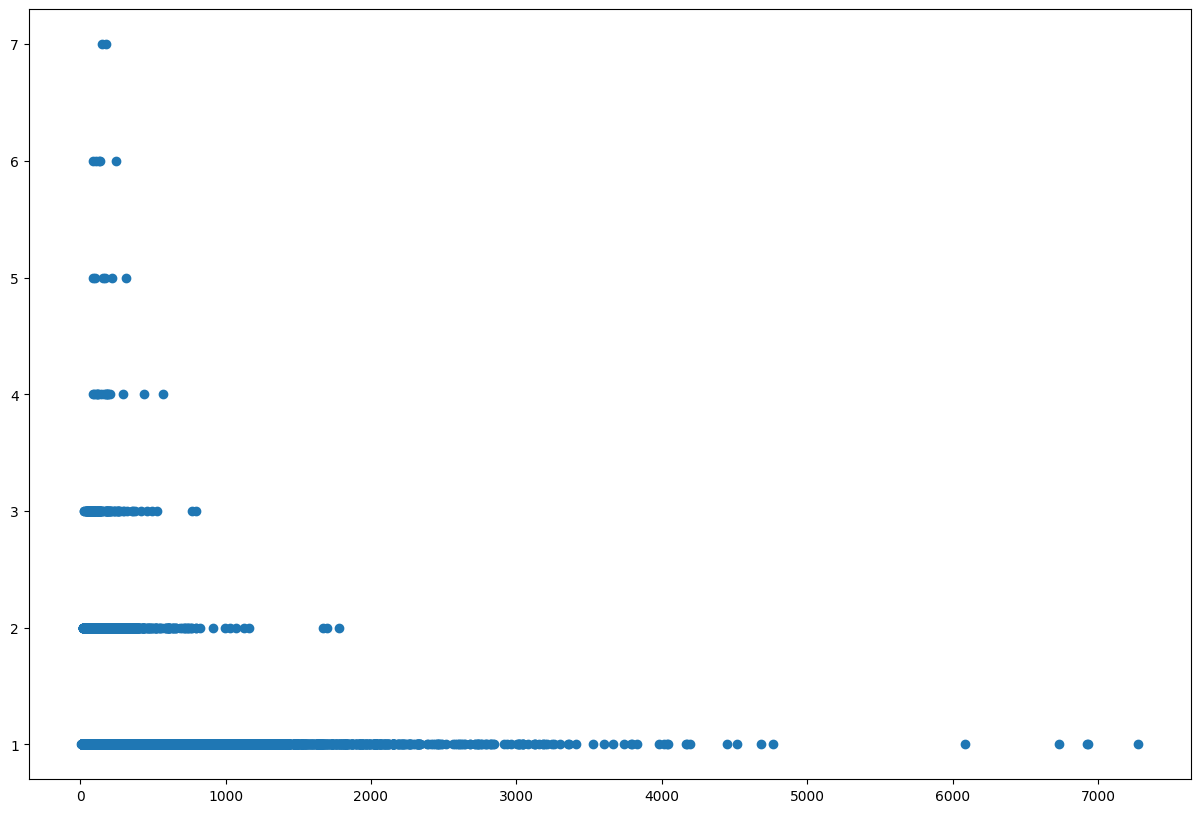

In [177]:
plt.figure(figsize=(15,10))
plt.scatter(rfm['Panier_moyen'], rfm['Frequence_achat'])

In [188]:
rfm.to_csv("/Users/garbamoussa/Downloads/TP-1-Customer-Intelligence-de-la-Data-au-Machine-Learning-main/data/rmf.csv")

In [178]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,geolocation_lat_y,geolocation_lng_y,payment_installments,payment_value,payment_type_boleto,payment_type_credit_card,payment_type_other,order_time,diff_estimated_real,delay
0,7f39ba4c9052be115350065d07583cac,d7fc82cbeafea77bd0a8fbbf6296e387,delivered,2017-10-18 08:16:34,2017-10-18 23:56:20,2017-10-20 14:29:01,2017-10-27 16:46:05,2017-11-09,9de5797cddb92598755a0f76383ddbbb,35490,...,-23.640444,-46.541742,0.0,916.02,0.0,1.0,0.0,9.0,-13.0,0
1,9dc8d1a6f16f1b89874c29c9d8d30447,d9442164acf4b03109425633efaa0cfc,delivered,2017-10-12 13:33:22,2017-10-12 13:49:22,2017-10-17 15:42:42,2017-10-24 20:17:44,2017-11-06,9915eb9f74b6c11aaf04833f65b00e93,38600,...,-23.640444,-46.541742,0.0,916.02,0.0,1.0,0.0,12.0,-13.0,0
2,d455a8cb295653b55abda06d434ab492,944b72539d7e1f7f7fc6e46639ef1fe3,delivered,2017-09-26 22:17:05,2017-09-27 22:24:16,2017-09-29 15:53:03,2017-10-07 16:12:47,2017-10-30,3c7e305796add66698959fc7ad176f6b,87502,...,-23.640444,-46.541742,0.0,916.02,0.0,1.0,0.0,10.0,-23.0,0
3,006e43460a55bc60c0a437521e426529,23bfd4316e261786deed5a08231c75bc,delivered,2017-05-11 00:24:35,2017-05-11 01:30:22,2017-05-12 12:26:32,2017-05-19 09:51:17,2017-06-02,1df0a296f852bdf1a17b085730f4b894,11431,...,-20.278513,-40.411675,0.0,142.06,0.0,1.0,0.0,8.0,-14.0,0
4,00dfb074b5c910fbd08e04691c4b712f,a5ced4926d7d8fa71e9be2b007720356,delivered,2017-06-08 19:43:35,2017-06-08 19:55:19,2017-06-09 15:12:41,2017-06-15 09:03:59,2017-07-10,94ea9edee3656707894565f35cb8570d,8671,...,-20.278513,-40.411675,0.0,134.57,0.0,1.0,0.0,6.0,-25.0,0


In [185]:
 pip install xlsxwriter

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [186]:
import xlsxwriter 

In [187]:
df.to_excel("/Users/garbamoussa/Downloads/TP-1-Customer-Intelligence-de-la-Data-au-Machine-Learning-main/data/df_prepared.xlsx",  engine='xlsxwriter')

## Modèles de clustering

### Clustering k-means

In [ ]:
x = np.array(rfm)

In [ ]:
x

In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(x)

In [ ]:
scaled_features

In [ ]:
kmeans_kwargs = {"init": "random",
                 "n_init": 10,
                 "max_iter": 300,
                 "random_state": 42}

In [ ]:
sse = []
scores = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_features)
    sse.append(kmeans.inertia_)
    scores.append(silhouette_score(scaled_features, kmeans.labels_))

In [ ]:
plt.figure(figsize=(16,8))
plt.plot(range(2, 8), sse)
plt.xticks(range(2, 8))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [ ]:
plt.figure(figsize=(16,8))
plt.plot(range(2, 8), scores)
plt.xticks(range(2, 8))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

In [ ]:
# Silhouette Score plot
kmeans = KMeans(n_clusters=4, **kmeans_kwargs)
kmeans.fit(scaled_features)

In [ ]:
kmeans.cluster_centers_

In [ ]:
from sklearn.metrics import silhouette_samples,silhouette_score

y_predict = kmeans.fit_predict(scaled_features)
centroids  = kmeans.cluster_centers_

In [ ]:
# get silhouette
silhouette_vals = silhouette_samples(scaled_features,y_predict)
#silhouette_vals
# silhouette plot
y_ticks = []
y_lower = y_upper = 0

In [ ]:
fig, ax = plt.subplots(figsize=(15,5))
  
for i,cluster in enumerate(np.unique(y_predict)):
    cluster_silhouette_vals = silhouette_vals[y_predict ==cluster]
    cluster_silhouette_vals.sort()
    y_upper += len(cluster_silhouette_vals)
    ax.barh(range(y_lower,y_upper),
            cluster_silhouette_vals,height =1);
    ax.text(-0.03,(y_lower+y_upper)/2,str(i+1))
    y_lower += len(cluster_silhouette_vals)
    
    # Get the average silhouette score 
    avg_score = np.mean(silhouette_vals)
    ax.axvline(avg_score,linestyle ='--',
               linewidth =2,color = 'green')
    ax.set_yticks([])
    ax.set_xlim([-0.1, 1])
    ax.set_xlabel('Silhouette coefficient values')
    ax.set_ylabel('Cluster labels')
    ax.set_title('Silhouette plot for the 4 clusters')

In [ ]:
score = silhouette_score(scaled_features, kmeans.labels_)

In [ ]:
score

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=3)
principalComponents = pca.fit_transform(scaled_features)

In [ ]:
# Plotting the variances for each PC
PC = range(1, pca.n_components_+1)
plt.bar(PC, pca.explained_variance_ratio_, color='gold')
plt.xlabel('Principal Components')
plt.ylabel('Variance %')
plt.xticks(PC)

# Putting components in a dataframe for later
PCA_components = pd.DataFrame(principalComponents)

In [ ]:
labels = kmeans.predict(scaled_features)

In [ ]:
plt.figure(figsize=(16,8))
plt.scatter(PCA_components[0], PCA_components[1], alpha=.3, c=labels)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

In [ ]:
plt.figure(figsize=(16,8))
plt.scatter(PCA_components[1], PCA_components[2], alpha=.3, c=labels)
plt.xlabel('PCA 2')
plt.ylabel('PCA 3')
plt.show()

In [ ]:
fig = plt.figure(figsize=(16,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(PCA_components[2], PCA_components[0], PCA_components[1], c=labels)

ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')

plt.show()

In [ ]:
tsne = TSNE(n_components=2, verbose=1, perplexity=40, n_iter=300)
tsne_results = tsne.fit_transform(scaled_features)

In [ ]:
import seaborn as sns

In [ ]:
plt.figure(figsize=(16,8))
plt.scatter(tsne_results[:,0], tsne_results[:,1], alpha=.3, c=labels)
plt.xlabel('tsne 1')
plt.ylabel('tsne 2')
plt.show()

In [ ]:
categories = rfm.columns

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
      r=kmeans.cluster_centers_[0],
      theta=categories,
      fill='toself',
      name='Cluster_1'
))
fig.add_trace(go.Scatterpolar(
      r=kmeans.cluster_centers_[1],
      theta=categories,
      fill='toself',
      name='Cluster_2'
))

fig.add_trace(go.Scatterpolar(
      r=kmeans.cluster_centers_[2],
      theta=categories,
      fill='toself',
      name='Cluster_3'
))

fig.add_trace(go.Scatterpolar(
      r=kmeans.cluster_centers_[3],
      theta=categories,
      fill='toself',
      name='Cluster_4'
))

fig.update_layout(
  polar=dict(
    radialaxis=dict(
      visible=True,
      range=[-1, 6.5]
    )),
  showlegend=True
)


fig.show()

### Classification hiérarchique

In [ ]:
rfm.shape

In [ ]:
def hier(X, n_clusters):
    ss = StandardScaler()
    X = ss.fit_transform(X)
    hier = AgglomerativeClustering(n_clusters=n_clusters)
    y_pred = hier.fit_predict(X)
    fig = plt.figure(figsize=(16,8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X[:,2], X[:,1], X[:,0], c=y_pred, cmap='Paired')
    plt.title("Hierarchical")

In [ ]:
rfmsample = rfm.sample(n = 10000)

In [ ]:
xsample = np.array(rfmsample)

In [ ]:
plt.figure(figsize=(16,8))
dendrogram = sch.dendrogram(sch.linkage(rfmsample, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

In [ ]:
plt.figure(figsize=(16,8))
hier(xsample, n_clusters = 3)

### DBScan

In [ ]:
# Compute DBSCAN
db = DBSCAN(eps=0.3, min_samples=10).fit(scaled_features)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

In [ ]:
# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print('Estimated number of clusters: %d' % n_clusters_)
print('Estimated number of noise points: %d' % n_noise_)
print("Silhouette Coefficient: %0.3f"
      % metrics.silhouette_score(scaled_features, labels))

In [ ]:
def dbscan(X, eps, min_samples):
    ss = StandardScaler()
    X = ss.fit_transform(X)
    db = DBSCAN(eps=eps, min_samples=min_samples)
    db.fit(X)
    y_pred = db.fit_predict(X)
    fig = plt.figure(figsize=(16,8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X[:,1], X[:,0], X[:,2], c=y_pred, cmap='Paired')
    plt.title("DBSCAN")

In [ ]:
plt.figure(figsize=(16,8))
dbscan(x, eps=0.5, min_samples=5)

## Stabilité des clusters dans le temps

### Création de subset par période de temps

In [ ]:
rfm['Days_since_last_order'].unique()

In [ ]:
rfm2016T4 = rfm.loc[rfm['Days_since_last_order'] > 730]

rfm2017T1 = rfm.loc[(rfm['Days_since_last_order'] <= 730) & (rfm['Days_since_last_order'] > 639) ]
rfm2017T2 = rfm.loc[(rfm['Days_since_last_order'] <= 639) & (rfm['Days_since_last_order'] > 548) ]
rfm2017T3 = rfm.loc[(rfm['Days_since_last_order'] <= 548) & (rfm['Days_since_last_order'] > 457) ]
rfm2017T4 = rfm.loc[(rfm['Days_since_last_order'] <= 457) & (rfm['Days_since_last_order'] > 365) ]

rfm2018T1 = rfm.loc[(rfm['Days_since_last_order'] <= 365) & (rfm['Days_since_last_order'] > 274) ]
rfm2018T2 = rfm.loc[(rfm['Days_since_last_order'] <= 274) & (rfm['Days_since_last_order'] > 183) ]
rfm2018T3 = rfm.loc[(rfm['Days_since_last_order'] <= 183) & (rfm['Days_since_last_order'] > 92) ]
rfm2018T4 = rfm.loc[rfm['Days_since_last_order'] <= 92]

In [ ]:
rfm2018T1

In [ ]:
#On ne prend pas en compte 2016 et 2018T4 car pas ou trop peu de données
print(rfm2016T4.shape)
print(rfm2017T2.shape)
print(rfm2018T3.shape)
print(rfm2018T4.shape)

In [ ]:
periode = [rfm2017T1, rfm2017T2, rfm2017T3, rfm2017T4, rfm2018T1, rfm2018T2, rfm2018T3]

### Clusteing (k-means) sur chaque subset

In [ ]:
# On vérifie que le nbre de cluster optimal est bien 4 
kmeans_kwargs = {"init": "k-means++",
                 "n_init": 10,
                 "max_iter": 300,
                 "random_state": 20}

sse = []
for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaler.fit_transform(rfm2017T1))
    sse.append(kmeans.inertia_)

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(range(2, 8), sse)
plt.xticks(range(2, 8))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [ ]:
 # Applique kmeans au premier trimestre 
ss = StandardScaler()
rfm2017T1_scaled = ss.fit_transform(rfm2017T1)
kmt0 = KMeans(n_clusters=4, init= 'k-means++', n_init= 10, max_iter= 300, random_state= 20)
kmt0.fit(rfm2017T1_scaled)
y_pred = kmt0.predict(rfm2017T1_scaled)

In [ ]:
rfm2017T1

In [ ]:
centroidst0 = kmt0.cluster_centers_
centroidst0

### Visualisation de l'évolution des clusters

In [ ]:
kmeans_kwargs = {"init": centroidst0,
                 "max_iter": 300,
                 "random_state": 20}

centro = []

for i in periode:
    print(i.shape)
        
    # Model
    ss = StandardScaler()
    X_scaled = ss.fit_transform(i)
    km = KMeans(n_clusters=4, **kmeans_kwargs)
    km.fit(X_scaled)
    y_pred = km.predict(X_scaled)
    i['label'] = y_pred
    # Visualisation
    fig = plt.figure(figsize=(16,8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_scaled[:,2], X_scaled[:,1], X_scaled[:,0], c=y_pred, cmap='Paired')
    plt.title("K-means")
    plt.show()
    #Centroides
    print(km.cluster_centers_)
    centro.append(km.cluster_centers_)
        

In [ ]:
centro

In [ ]:
names = ['centroid1','centroid2','centroid3']
df_centroids = pd.DataFrame(columns=names)

for i in range(7):
    centro[i] = pd.DataFrame(centro[i], columns=names)
    centro[i]['periode'] = i+1
    df_centroids = df_centroids.append(centro[i])

In [ ]:
df_centroids

In [ ]:
# Evolution des centroids en fonction de la période

fig = plt.figure(figsize=(16,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_centroids['centroid2'], df_centroids['centroid1'], df_centroids['centroid3'], 
           c=df_centroids['periode'], cmap='Paired')
plt.title("K-means centroids")
plt.show()

In [ ]:
# Prédiction de cluster sur le modèle de 2017 T1 (t0)
rfm2017T2['label_t0'] = kmt0.predict(ss.fit_transform(rfm2017T2.iloc[:, 0:3]))
rfm2017T3['label_t0'] = kmt0.predict(ss.fit_transform(rfm2017T3.iloc[:, 0:3]))
rfm2017T4['label_t0'] = kmt0.predict(ss.fit_transform(rfm2017T4.iloc[:, 0:3]))

rfm2018T1['label_t0'] = kmt0.predict(ss.fit_transform(rfm2018T1.iloc[:, 0:3]))
rfm2018T2['label_t0'] = kmt0.predict(ss.fit_transform(rfm2018T2.iloc[:, 0:3]))
rfm2018T3['label_t0'] = kmt0.predict(ss.fit_transform(rfm2018T3.iloc[:, 0:3]))


In [ ]:
rfm2017T2

**Calcul ARI**
: L’appel à metrics.adjusted_rand_score() compare le partitionnement obtenu par la classification automatique (étiquettes de 
groupe de pred) avec le partitionnement correspondant aux groupes définis au départ (étiquettes stockées dans labels).

In [ ]:
# Calcul de l'ARI pour chaque période par rapport à T0 (2017t1)
metrics.adjusted_rand_score(rfm2017T2['label'], rfm2017T2['label_t0'])

In [ ]:
print(metrics.adjusted_rand_score(rfm2017T3['label'], rfm2017T3['label_t0']))
print(metrics.adjusted_rand_score(rfm2017T4['label'], rfm2017T4['label_t0']))
print(metrics.adjusted_rand_score(rfm2018T1['label'], rfm2018T1['label_t0']))
print(metrics.adjusted_rand_score(rfm2018T2['label'], rfm2018T2['label_t0']))
print(metrics.adjusted_rand_score(rfm2018T3['label'], rfm2018T3['label_t0']))

# Clustering sur données élargies

**Features possibles**
comportement du client ?
    categorie de produit est le plus achetées (en regroupant les categ peu représentées)
    note du premier achat
    zone géographique des clients (en regroupant les Etats peu représentés)
    type de paiement
    achat en plusieurs fois ou pas
    frais de port
    différence entre date de commande et date estimée de livraison (=délai estimé de commande)

## Création dataframe données élargies

In [ ]:
df

In [ ]:
segm = df[['customer_unique_id','order_id','order_purchase_timestamp','geolocation_lat_x','geolocation_lng_x',
           'payment_value','diff_estimated_real','payment_type_credit_card','payment_type_other',
           'review_score']]
segm = segm.dropna()
segm

In [ ]:
segm.shape

In [ ]:
segm['order_purchase_timestamp'] = pd.to_datetime(segm['order_purchase_timestamp'])

# On positionne le projet à la fin de l'année 2018 et on calcule le nombre de jours depuis la dernière commande
segm['Days_since_last_order'] = (pd.to_datetime('2018-12-31 23:59:59') - segm['order_purchase_timestamp']).dt.days

In [ ]:
# Calcul du nombre de commandes effectuées et moyenne des autres variables
freq_panier = segm.groupby("customer_unique_id").agg({'Days_since_last_order': "nunique",
                                                      'payment_value': "mean",
                                                      'review_score': "mean",
                                                      'diff_estimated_real' : "mean",
                                                      'payment_type_credit_card': "mean",
                                                      'payment_type_other': "mean",
                                                      'geolocation_lat_x': "mean",
                                                      'geolocation_lng_x': "mean"}).reset_index()

freq_panier = freq_panier.sort_values(by='Days_since_last_order').rename(columns={"Days_since_last_order": "Frequence_achat",
                                                                                 "payment_value": "Panier_moyen",
                                                                                 "review_score" : "score_moyen",
                                                                                 "diff_estimated_real" : 'respect_delai',
                                                                                 "payment_type_credit_card" :'paye_cb',
                                                                                 "payment_type_other" : 'paye_autres',
                                                                                 "geolocation_lat_x" : 'latitude',
                                                                                 "geolocation_lng_x": 'longitude'})
freq_panier


In [ ]:
segm = segm.merge(freq_panier, how = 'left', on ='customer_unique_id')
segm

In [ ]:
print("Nombre de lignes dans le dataset : ",len(segm))
nansegm = pd.DataFrame({'colonne':segm.isna().sum().index,'nbre de nan':segm.isna().sum().values})
nansegm

In [ ]:
# On ne conserve que la dernière commande en date 
segm = segm.sort_values('Days_since_last_order').drop_duplicates(subset='customer_unique_id', keep='first')
segm = segm.reset_index()
segm = segm[['Days_since_last_order','Frequence_achat','Panier_moyen','score_moyen','respect_delai',
             'paye_cb','paye_autres','latitude','longitude']]
segm

## Modèles de clustering

### Clustering K-means

In [ ]:
z = np.array(segm)
z

In [ ]:
scaler = StandardScaler()
scaled_z = scaler.fit_transform(z)

In [ ]:
scaled_z

In [ ]:
kmeans_kwargs = {"init": "random",
                 "n_init": 10,
                 "max_iter": 300,
                 "random_state": 42}

zsse = []
zscores = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_z)
    zsse.append(kmeans.inertia_)
    zscores.append(silhouette_score(scaled_z, kmeans.labels_))

In [ ]:
plt.figure(figsize=(16,8))
plt.plot(range(2, 8), zsse)
plt.xticks(range(2, 8))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [ ]:
plt.figure(figsize=(16,8))
plt.plot(range(2, 8), zscores)
plt.xticks(range(2, 8))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

**Visualisation**

In [ ]:
kmeans = KMeans(n_clusters=6, **kmeans_kwargs)
kmeans.fit(scaled_z)

In [ ]:
kmeans.cluster_centers_

In [ ]:
pca = PCA(n_components=4)
principalComponents = pca.fit_transform(scaled_z)

In [ ]:
# Plotting the variances for each PC
PC = range(1, pca.n_components_+1)
plt.bar(PC, pca.explained_variance_ratio_, color='gold')
plt.xlabel('Principal Components')
plt.ylabel('Variance %')
plt.xticks(PC)

# Putting components in a dataframe for later
PCA_components = pd.DataFrame(principalComponents)

In [ ]:
labels = kmeans.predict(scaled_z)

In [ ]:
plt.figure(figsize=(16,8))
plt.scatter(PCA_components[0], PCA_components[1], alpha=.3, c=labels)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

In [ ]:
fig = plt.figure(figsize=(16,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(PCA_components[0], PCA_components[1], PCA_components[2], c=labels)

ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')

plt.show()

In [ ]:
plt.figure(figsize=(16,8))
plt.scatter(PCA_components[2], PCA_components[3], alpha=.3, c=labels)
plt.xlabel('PCA 3')
plt.ylabel('PCA 4')
plt.show()

**Spider Chart**

In [ ]:
segm.head()

In [ ]:
segm.columns

In [ ]:
kmeans.cluster_centers_

In [ ]:
categories = segm.columns

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
      r=kmeans.cluster_centers_[0],
      theta=categories,
      fill='toself',
      name='Cluster_1'
))
fig.add_trace(go.Scatterpolar(
      r=kmeans.cluster_centers_[1],
      theta=categories,
      fill='toself',
      name='Cluster_2'
))

fig.add_trace(go.Scatterpolar(
      r=kmeans.cluster_centers_[2],
      theta=categories,
      fill='toself',
      name='Cluster_3'
))

fig.add_trace(go.Scatterpolar(
      r=kmeans.cluster_centers_[3],
      theta=categories,
      fill='toself',
      name='Cluster_4'
))

fig.add_trace(go.Scatterpolar(
      r=kmeans.cluster_centers_[4],
      theta=categories,
      fill='toself',
      name='Cluster_5'
))

fig.add_trace(go.Scatterpolar(
      r=kmeans.cluster_centers_[5],
      theta=categories,
      fill='toself',
      name='Cluster_6'
))

fig.update_layout(
  polar=dict(
    radialaxis=dict(
      visible=True,
      range=[-1, 2]
    )),
  showlegend=True
)


fig.show()

### Classification hiérarchique

In [ ]:
segmsample = segm.sample(n = 10000)
zsample = np.array(segmsample)

In [ ]:
plt.figure(figsize=(16,8))
dendrogram = sch.dendrogram(sch.linkage(segmsample, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

In [ ]:
plt.figure(figsize=(16,8))
hier(zsample, n_clusters = 3)

### DBSCAN 

In [ ]:
# Compute DBSCAN
db = DBSCAN(eps=0.3, min_samples=10).fit(scaled_z)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

In [ ]:
# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print('Estimated number of clusters: %d' % n_clusters_)
print('Estimated number of noise points: %d' % n_noise_)
print("Silhouette Coefficient: %0.3f"
      % metrics.silhouette_score(scaled_z, labels))

In [ ]:
plt.figure(figsize=(16,8))
dbscan(z, eps=0.5, min_samples=5)

## Stabilité des clusters dans le temps

### Création de subset par période de temps

In [ ]:
segm2016T4 = segm.loc[segm['Days_since_last_order'] > 730]

segm2017T1 = segm.loc[(segm['Days_since_last_order'] <= 730) & (segm['Days_since_last_order'] > 639) ]
segm2017T2 = segm.loc[(segm['Days_since_last_order'] <= 639) & (segm['Days_since_last_order'] > 548) ]
segm2017T3 = segm.loc[(segm['Days_since_last_order'] <= 548) & (segm['Days_since_last_order'] > 457) ]
segm2017T4 = segm.loc[(segm['Days_since_last_order'] <= 457) & (segm['Days_since_last_order'] > 365) ]

segm2018T1 = segm.loc[(segm['Days_since_last_order'] <= 365) & (segm['Days_since_last_order'] > 274) ]
segm2018T2 = segm.loc[(segm['Days_since_last_order'] <= 274) & (segm['Days_since_last_order'] > 183) ]
segm2018T3 = segm.loc[(segm['Days_since_last_order'] <= 183) & (segm['Days_since_last_order'] > 92) ]
segm2018T4 = segm.loc[segm['Days_since_last_order'] <= 92]

In [ ]:
segm2018T1

In [ ]:
#On ne prend pas en compte 2016 et 2018T4 car pas ou trop peu de données
print(segm2016T4.shape)
print(segm2017T2.shape)
print(segm2018T3.shape)
print(segm2018T4.shape)

In [ ]:
periodesegm = [segm2017T1, segm2017T2, segm2017T3, segm2017T4, segm2018T1, segm2018T2, segm2018T3]

### Clustering (k-means) sur chaque subset 

In [ ]:
# On vérifie que le nbre de cluster optimal est bien 6
kmeans_kwargs = {"init": "k-means++",
                 "n_init": 10,
                 "max_iter": 300,
                 "random_state": 20}

sse = []
for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaler.fit_transform(segm2017T1))
    sse.append(kmeans.inertia_)

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(range(2, 8), sse)
plt.xticks(range(2, 8))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [ ]:
 # Applique kmeans au premier trimestre 
ss = StandardScaler()
segm2017T1_scaled = ss.fit_transform(segm2017T1)
kmt0 = KMeans(n_clusters=5, init= 'k-means++', n_init= 10, max_iter= 300, random_state= 20)
kmt0.fit(segm2017T1_scaled)
y_pred = kmt0.predict(segm2017T1_scaled)

In [ ]:
centroidst0 = kmt0.cluster_centers_
centroidst0

### Visualisation de l'évolution des clusters

In [ ]:
kmeans_kwargs = {"init": centroidst0,
                 "max_iter": 300,
                 "random_state": 20}

centro = []

for i in periodesegm:
    print(i.shape)
        
    # Model
    ss = StandardScaler()
    X_scaled = ss.fit_transform(i)
    km = KMeans(n_clusters=5, **kmeans_kwargs)
    km.fit(X_scaled)
    y_pred = km.predict(X_scaled)
    i['label'] = y_pred
    # Visualisation
    fig = plt.figure(figsize=(16,8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_scaled[:,2], X_scaled[:,1], X_scaled[:,0], c=y_pred, cmap='Paired')
    plt.title("K-means")
    plt.show()
    #Centroides
    print(km.cluster_centers_)
    centro.append(km.cluster_centers_)

In [ ]:
centro

In [ ]:
names = ['coord1','coord2','coord3','coord4','coord5','coord6','coord7','coord8','coord9']
df_centroids = pd.DataFrame(columns=names)

for i in range(7):
    centro[i] = pd.DataFrame(centro[i], columns=names)
    centro[i]['periode'] = i+1
    df_centroids = df_centroids.append(centro[i])

In [ ]:
df_centroids

### ARI

In [ ]:
# Prédiction de cluster sur le modèle de 2017 T1 (t0)
segm2017T2['label_t0'] = kmt0.predict(ss.fit_transform(segm2017T2.iloc[:, 0:9]))
segm2017T3['label_t0'] = kmt0.predict(ss.fit_transform(segm2017T3.iloc[:, 0:9]))
segm2017T4['label_t0'] = kmt0.predict(ss.fit_transform(segm2017T4.iloc[:, 0:9]))

segm2018T1['label_t0'] = kmt0.predict(ss.fit_transform(segm2018T1.iloc[:, 0:9]))
segm2018T2['label_t0'] = kmt0.predict(ss.fit_transform(segm2018T2.iloc[:, 0:9]))
segm2018T3['label_t0'] = kmt0.predict(ss.fit_transform(segm2018T3.iloc[:, 0:9]))

In [ ]:
segm2017T2

**Calcul ARI**
: L’appel à metrics.adjusted_rand_score() compare le partitionnement obtenu par la classification automatique (étiquettes de 
groupe de pred) avec le partitionnement correspondant aux groupes définis au départ (étiquettes stockées dans labels).

In [ ]:
# Calcul de l'ARI pour chaque période par rapport à T0 (2017t1)


In [ ]:
ARI = []
ARI.append(metrics.adjusted_rand_score(segm2017T2['label'], segm2017T2['label_t0']))
ARI.append(metrics.adjusted_rand_score(segm2017T3['label'], segm2017T3['label_t0']))
ARI.append(metrics.adjusted_rand_score(segm2017T4['label'], segm2017T4['label_t0']))
ARI.append(metrics.adjusted_rand_score(segm2018T1['label'], segm2018T1['label_t0']))
ARI.append(metrics.adjusted_rand_score(segm2018T2['label'], segm2018T2['label_t0']))
ARI.append(metrics.adjusted_rand_score(segm2018T3['label'], segm2018T3['label_t0']))

In [ ]:
ARI

In [ ]:
periodeaxis = [ "segm2017T2", "segm2017T3", "segm2017T4", "segm2018T1", "segm2018T2", "segm2018T3"]

In [ ]:
from pylab import *
plt.figure(figsize=(10,6))
plot(periodeaxis, ARI)